# **TEL351: Seminario de Telemática**
## **Problema 2: Dinámicas de Opinión y Polarización en Redes Sociales durante una Crisis Nacional**

### Pedro Arce

## **Introducción:**

Este notebook analiza la conversación en línea en torno al apagón eléctrico nacional ocurrido en Chile en febrero de 2025, utilizando datos de Reddit (principalmente del subreddit r/chile). El objetivo es estudiar no solo el tono de las opiniones expresadas, sino también cómo se organizan los usuarios en la red, cómo se propagan esas opiniones y qué tan posible es que se generen dinámicas de consenso, polarización o fragmentación en torno al evento.

Las redes sociales se han convertido en un espacio central para la formación de opinión pública, pero también para la difusión de desinformación, narrativas extremas y cámaras de eco. A través de técnicas de análisis de redes, análisis de sentimientos y modelos de dinámica de opinión, este trabajo busca explorar hasta qué punto la estructura de la red y las interacciones entre usuarios contribuyen a reforzar o moderar estas dinámicas.

### **Objetivos:**



1. Recolectar y preprocesar publicaciones y comentarios de Reddit relacionados con el apagón de febrero de 2025 en Chile.

2. Aplicar análisis de sentimientos para caracterizar el tono (negativo, neutro, positivo) de la conversación.

3. Construir un grafo de interacciones entre usuarios (respuestas en hilos) e identificar comunidades y patrones de agrupamiento ideológico.

4. Modelar la dinámica de opinión sobre la red (modelo de DeGroot) y evaluar si la conversación tiende al consenso, polarización o fragmentación.

5. Simular intervenciones en la red (como eliminación o refuerzo de conexiones entre comunidades) y analizar su efecto sobre la evolución de las opiniones.

6. Discutir las implicancias sociales y éticas de los resultados, en particular en relación con el diseño de plataformas digitales y la responsabilidad de los usuarios.

In [1]:
###Instalación de librerias necesarias
!pip install jupyter pandas numpy networkx matplotlib pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.6 MB/s eta 0:00:00


In [2]:
###1. Imports de librerías para todo el notebook

import json
import glob
import os
import pandas as pd
import numpy as np
import re
import unicodedata
import html
from pysentimiento import create_analyzer
import networkx as nx
from networkx.algorithms import community
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import random

#Config inicial
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 10)

DATA_DIR = "data"

In [3]:
###2. Localizar archivos .json de Reddit

json_pattern = os.path.join(DATA_DIR, "apagon_thread*.json")
json_files = glob.glob(json_pattern)

print("Archivos JSON encontrados:")
for f in json_files:
    print("  -", f)

len(json_files)

Archivos JSON encontrados:
  - data/apagon_thread2.json
  - data/apagon_thread1.json
  - data/apagon_thread4.json
  - data/apagon_thread3.json


4

In [4]:
###3. Funciones de parsing del JSON de Reddit

def parse_post_metadata(thread_json, source_filename=None):
    """
    Extrae metadatos del post principal (OP) desde la primera parte del JSON
    """
    post_part = thread_json[0]["data"]["children"][0]["data"]
    post_id = post_part.get("id")
    title = post_part.get("title")
    subreddit = post_part.get("subreddit")
    permalink = post_part.get("permalink")
    created_utc = post_part.get("created_utc")
    score = post_part.get("score")
    num_comments = post_part.get("num_comments")

    return {
        "thread_id": post_id,
        "thread_title": title,
        "thread_subreddit": subreddit,
        "thread_url": f"https://www.reddit.com{permalink}" if permalink else None,
        "thread_created_utc": created_utc,
        "thread_score": score,
        "thread_num_comments": num_comments,
        "thread_source_file": source_filename,
    }


def flatten_comments(comments_listing, thread_meta):
    """
    Aplana la estructura de comentarios (árbol) de Reddit en una lista de dicts

    comments_listing: thread_json[1]["data"]["children"]
    thread_meta: dict con info del hilo
    """
    rows = []

    def _walk(children):
        for child in children:
            kind = child.get("kind")
            data = child.get("data", {})

            if kind == "t1":
                comment_id = data.get("id")
                author = data.get("author")
                body = data.get("body")
                score = data.get("score")
                created_utc = data.get("created_utc")
                parent_fullname = data.get("parent_id")  #"t1_xxx" o "t3_xxx"
                permalink = data.get("permalink")

                row = {
                    **thread_meta,
                    "comment_id": comment_id,
                    "comment_parent_fullname": parent_fullname,
                    "comment_author": author,
                    "comment_body": body,
                    "comment_score": score,
                    "comment_created_utc": created_utc,
                    "comment_permalink": (
                        f"https://www.reddit.com{permalink}" if permalink else None
                    ),
                }
                rows.append(row)

                #Procesar respuestas (replies)
                replies = data.get("replies")
                if isinstance(replies, dict):
                    repl_children = replies.get("data", {}).get("children", [])
                    _walk(repl_children)

            elif kind == "more":
                #"more" indica que hay más comentarios que el JSON no incluye por defecto
                continue

    _walk(comments_listing)
    return rows

In [5]:
###4. Procesar todos los archivos JSON y combinarlos

all_rows = []

for filepath in json_files:
    print(f"Procesando archivo: {filepath}")

    try:
        with open(filepath, "r", encoding="utf-8") as f:
            thread_json = json.load(f)

        #Metadatos del hilo (1er elemento del JSON)
        thread_meta = parse_post_metadata(thread_json, source_filename=os.path.basename(filepath))

        #Comentarios (2do elemento del JSON)
        comments_listing = thread_json[1]["data"]["children"]
        rows = flatten_comments(comments_listing, thread_meta)

        print(f"  Hilo {thread_meta['thread_id']} - '{thread_meta['thread_title'][:60]}...' -> {len(rows)} comentarios")
        all_rows.extend(rows)

    except Exception as e:
        print(f"  !!Error procesando {filepath}: {e}")

print("Total de comentarios en todos los hilos:", len(all_rows))

Procesando archivo: data/apagon_thread2.json
  Hilo 1iypbv9 - 'Experiencia y enseñanzas que dejó este apagon...' -> 23 comentarios
Procesando archivo: data/apagon_thread1.json
  Hilo 1jft2e3 - 'Correos evidencian protección del Sernac a distribuidoras el...' -> 23 comentarios
Procesando archivo: data/apagon_thread4.json
  Hilo 1iy1x0k - 'Corte de luz en Chile: reportan interrupción del suministro ...' -> 172 comentarios
Procesando archivo: data/apagon_thread3.json
  Hilo 1iydhc4 - '¿Qué hicieron en su día sin luz...' -> 64 comentarios
Total de comentarios en todos los hilos: 282


In [6]:
###5. DataFrame final y guardado en CSV

df = pd.DataFrame(all_rows)
print("Dimensiones del DataFrame:", df.shape)
df.head()

#Guardar dataset listo para las siguientes etapas (limpieza, sentimiento, redes)
output_path = "reddit_apagon_chile_2025_localjson.csv"
df.to_csv(output_path, index=False, encoding="utf-8")

output_path

Dimensiones del DataFrame: (282, 15)


'reddit_apagon_chile_2025_localjson.csv'

In [7]:
#1. Función de limpieza de texto
def clean_text(text):
    if pd.isna(text):
        return ""

    #Aseguramos que sea string
    text = str(text)

    #1) Decodificar entidades HTML ( &amp;, &quot;, etc. )
    text = html.unescape(text)

    #2) Eliminar etiquetas HTML simples si quedaron (por si usaste *_html)
    text = re.sub(r"<.*?>", " ", text)

    #3) Normalizar Unicode (asegura que tildes y ñ queden bien)
    text = unicodedata.normalize("NFC", text)

    #4) Quitar caracteres de control raros (saltos de línea, tabs, etc.)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")

    #5) Eliminar emojis y símbolos muy raros, pero conservar letras, números, espacios, puntuación básica y tildes/ñ
    text = re.sub(
        r"[^\w\s\.,;:\?\!\-\'\"@/()\[\]¿¡áéíóúÁÉÍÓÚñÑ]",
        " ",
        text
    )

    #6) Compactar espacios múltiples
    text = re.sub(r"\s+", " ", text).strip()

    #7) converitr a ascii
    text_ascii = (
        unicodedata.normalize("NFD", text)
        .encode("ascii", "ignore")
        .decode("utf-8")
    )
    text = text_ascii


    return text

#2. Cargar CSV original
df = pd.read_csv("reddit_apagon_chile_2025_localjson.csv", encoding="utf-8")

#3. Aplicar limpieza a TODAS las columnas de tipo texto (object)
text_cols = df.select_dtypes(include=["object"]).columns

for col in text_cols:
    df[col] = df[col].apply(clean_text)

#4. Guardar CSV limpio (sobreescritura)
df.to_csv("reddit_apagon_chile_2025_localjson.csv", index=False, encoding="utf-8")

df.head()

,thread_id,thread_title,thread_subreddit,thread_url,thread_created_utc,thread_score,thread_num_comments,thread_source_file,comment_id,comment_parent_fullname,comment_author,comment_body,comment_score,comment_created_utc,comment_permalink
0,1iypbv9,Experiencia y ensenanzas que dejo este apagon,chile,https://www.reddit.com/r/chile/comments/1iypbv9/experiencia_y_ensenanzas_que_dejo_este_apagon/,1.740582e+09,0,23,apagon_thread2.json,mew7kp5,t3_1iypbv9,FullMud4224,"Al igual que con cada catastrofe. Todo el mundo opinara de lo importante que es tener respaldos, planes de contingencia, estar preparados, etc, etc. A lo dias se procedera a no hacer nada, se olvi...",20,1.740582e+09,https://www.reddit.com/r/chile/comments/1iypbv9/experiencia_y_ensenanzas_que_dejo_este_apagon/mew7kp5/
1,1iypbv9,Experiencia y ensenanzas que dejo este apagon,chile,https://www.reddit.com/r/chile/comments/1iypbv9/experiencia_y_ensenanzas_que_dejo_este_apagon/,1.740582e+09,0,23,apagon_thread2.json,mex47ol,t1_mew7kp5,Tuna_Melt_Sandwich,"No se yo tengo mis generadores, los hecho a andar al menos una vez al mes y sus revisiones cada ano. Siempre tengo su bidon de combustible y se va usando (pues la bencina dura un poco mas de medio...",2,1.740591e+09,https://www.reddit.com/r/chile/comments/1iypbv9/experiencia_y_ensenanzas_que_dejo_este_apagon/mex47ol/
2,1iypbv9,Experiencia y ensenanzas que dejo este apagon,chile,https://www.reddit.com/r/chile/comments/1iypbv9/experiencia_y_ensenanzas_que_dejo_este_apagon/,1.740582e+09,0,23,apagon_thread2.json,mpidvq8,t1_mew7kp5,lasergun23,Y asi ha sucedido ironicamente,1,1.745859e+09,https://www.reddit.com/r/chile/comments/1iypbv9/experiencia_y_ensenanzas_que_dejo_este_apagon/mpidvq8/
3,1iypbv9,Experiencia y ensenanzas que dejo este apagon,chile,https://www.reddit.com/r/chile/comments/1iypbv9/experiencia_y_ensenanzas_que_dejo_este_apagon/,1.740582e+09,0,23,apagon_thread2.json,mew814x,t1_mew7kp5,ChileanChuckle,"Mal ahi po, es importante prepararse tanto para uno como para la comunidad. En lo personal espero llevar este tipo de plan de contingencia a mi pasaje con el tiempo, ojala forjar una comunidad mas...",-1,1.740582e+09,https://www.reddit.com/r/chile/comments/1iypbv9/experiencia_y_ensenanzas_que_dejo_este_apagon/mew814x/
4,1iypbv9,Experiencia y ensenanzas que dejo este apagon,chile,https://www.reddit.com/r/chile/comments/1iypbv9/experiencia_y_ensenanzas_que_dejo_este_apagon/,1.740582e+09,0,23,apagon_thread2.json,mewlrvn,t1_mew814x,FullMud4224,Yo implementare mi propia central nuclear :D,1,1.740586e+09,https://www.reddit.com/r/chile/comments/1iypbv9/experiencia_y_ensenanzas_que_dejo_este_apagon/mewlrvn/


## 1.2 Análisis de sentimientos

In [8]:
#Cargar el dataset base (el que generaste a partir de los JSON)
df = pd.read_csv("reddit_apagon_chile_2025_localjson.csv", encoding="utf-8")

print(df.shape)
df.head()

#Eliminar comentarios borrados o removidos
mask_valid = ~df["comment_body"].fillna("").str.lower().isin(["[deleted]", "[removed]"])
df = df[mask_valid].copy()

#Eliminar comentarios muy cortos (ej: solo 1–2 caracteres)
df = df[df["comment_body"].fillna("").str.strip().str.len() > 2].copy()

print("Comentarios útiles:", df.shape[0])

(282, 15)
Comentarios útiles: 270


In [9]:
def clean_text_for_sentiment(text):
    if pd.isna(text):
        return ""

    text = str(text)

    #1) Decodificar entidades HTML (&amp;, &quot;, etc.)
    text = html.unescape(text)

    #2) Eliminar etiquetas HTML simples si las hubiera
    text = re.sub(r"<.*?>", " ", text)

    #3) Normalizar Unicode (asegura que tildes y ñ queden bien)
    text = unicodedata.normalize("NFC", text)

    #4) Quitar saltos de línea, tabs, etc.
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")

    #5) Quitar URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    #6) Quitar algunos símbolos raros pero conservar letras, números, puntuación básica y tildes/ñ
    text = re.sub(
        r"[^\w\s\.,;:\?\!\-\'\"@/()\[\]¿¡áéíóúÁÉÍÓÚñÑ]",
        " ",
        text
    )

    #7) Pasar a minúsculas (opcional pero suele ayudar)
    text = text.lower()

    #8) Compactar espacios múltiples
    text = re.sub(r"\s+", " ", text).strip()

    return text

#App limpieza al cuerpo del comentario
df["comment_body_clean"] = df["comment_body"].apply(clean_text_for_sentiment)

df[["comment_body", "comment_body_clean"]].head(10)

,comment_body,comment_body_clean
0,"Al igual que con cada catastrofe. Todo el mundo opinara de lo importante que es tener respaldos, planes de contingencia, estar preparados, etc, etc. A lo dias se procedera a no hacer nada, se olvi...","al igual que con cada catastrofe. todo el mundo opinara de lo importante que es tener respaldos, planes de contingencia, estar preparados, etc, etc. a lo dias se procedera a no hacer nada, se olvi..."
1,"No se yo tengo mis generadores, los hecho a andar al menos una vez al mes y sus revisiones cada ano. Siempre tengo su bidon de combustible y se va usando (pues la bencina dura un poco mas de medio...","no se yo tengo mis generadores, los hecho a andar al menos una vez al mes y sus revisiones cada ano. siempre tengo su bidon de combustible y se va usando (pues la bencina dura un poco mas de medio..."
2,Y asi ha sucedido ironicamente,y asi ha sucedido ironicamente
3,"Mal ahi po, es importante prepararse tanto para uno como para la comunidad. En lo personal espero llevar este tipo de plan de contingencia a mi pasaje con el tiempo, ojala forjar una comunidad mas...","mal ahi po, es importante prepararse tanto para uno como para la comunidad. en lo personal espero llevar este tipo de plan de contingencia a mi pasaje con el tiempo, ojala forjar una comunidad mas..."
4,Yo implementare mi propia central nuclear :D,yo implementare mi propia central nuclear :d
5,"Lo que yo aprendi es siempre tener los telefonos cargados y tener aunque sea una reserva de agua considerable para la casa, literalmente mi casa tenia una reserva de agua de 2 bidones enteros pero...","lo que yo aprendi es siempre tener los telefonos cargados y tener aunque sea una reserva de agua considerable para la casa, literalmente mi casa tenia una reserva de agua de 2 bidones enteros pero..."
6,No se si alguien lo tendra grabado pero el cielo nocturnl se vio bonito. Pero igual tabien estaria bacan ver como se vio Chile desde la ISS de noche xD,no se si alguien lo tendra grabado pero el cielo nocturnl se vio bonito. pero igual tabien estaria bacan ver como se vio chile desde la iss de noche xd
7,Que tengo que comprar un cargador externo para el celu.,que tengo que comprar un cargador externo para el celu.
8,Si puedes que tenga para carga solar y radio integrada,si puedes que tenga para carga solar y radio integrada
9,Algun datito?,algun datito?


In [10]:
#Crear analizador de sentimiento en español
analyzer = create_analyzer(task="sentiment", lang="es")

label_map = {
    "POS": "positivo",
    "NEG": "negativo",
    "NEU": "neutro",
}

score_map = {
    "POS": 1.0,
    "NEU": 0.0,
    "NEG": -1.0,
}

def analyze_sentiment(text):
    text = str(text).strip()
    if not text:
        return pd.Series({
            "sentiment_label": "neutro",
            "sentiment_score": 0.0,
            "sent_pos": np.nan,
            "sent_neu": np.nan,
            "sent_neg": np.nan,
        })

    pred = analyzer.predict(text)

    label = label_map.get(pred.output, "neutro")
    score = score_map.get(pred.output, 0.0)

    return pd.Series({
        "sentiment_label": label,
        "sentiment_score": score,
        "sent_pos": float(pred.probas.get("POS", np.nan)),
        "sent_neu": float(pred.probas.get("NEU", np.nan)),
        "sent_neg": float(pred.probas.get("NEG", np.nan)),
    })

sentiment_cols = df["comment_body_clean"].apply(analyze_sentiment)
df = pd.concat([df, sentiment_cols], axis=1)

df[["comment_body_clean", "sentiment_label", "sentiment_score", "sent_pos", "sent_neu", "sent_neg"]].head(10)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

,comment_body_clean,sentiment_label,sentiment_score,sent_pos,sent_neu,sent_neg
0,"al igual que con cada catastrofe. todo el mundo opinara de lo importante que es tener respaldos, planes de contingencia, estar preparados, etc, etc. a lo dias se procedera a no hacer nada, se olvi...",negativo,-1.0,0.006331,0.082928,0.910741
1,"no se yo tengo mis generadores, los hecho a andar al menos una vez al mes y sus revisiones cada ano. siempre tengo su bidon de combustible y se va usando (pues la bencina dura un poco mas de medio...",neutro,0.0,0.034779,0.751009,0.214212
2,y asi ha sucedido ironicamente,neutro,0.0,0.049723,0.576486,0.373792
3,"mal ahi po, es importante prepararse tanto para uno como para la comunidad. en lo personal espero llevar este tipo de plan de contingencia a mi pasaje con el tiempo, ojala forjar una comunidad mas...",negativo,-1.0,0.021266,0.176095,0.802639
4,yo implementare mi propia central nuclear :d,positivo,1.0,0.582319,0.407971,0.009711
5,"lo que yo aprendi es siempre tener los telefonos cargados y tener aunque sea una reserva de agua considerable para la casa, literalmente mi casa tenia una reserva de agua de 2 bidones enteros pero...",neutro,0.0,0.104883,0.780159,0.114958
6,no se si alguien lo tendra grabado pero el cielo nocturnl se vio bonito. pero igual tabien estaria bacan ver como se vio chile desde la iss de noche xd,positivo,1.0,0.661220,0.314170,0.024610
7,que tengo que comprar un cargador externo para el celu.,neutro,0.0,0.030013,0.726087,0.243901
8,si puedes que tenga para carga solar y radio integrada,neutro,0.0,0.138321,0.837602,0.024078
9,algun datito?,neutro,0.0,0.063361,0.897450,0.039189


In [11]:
###Resumen de resultados

#Distrib de etiquetas
dist = df["sentiment_label"].value_counts(normalize=False).to_frame("count")
dist["percent"] = (dist["count"] / dist["count"].sum() * 100).round(2)
dist

,count,percent
sentiment_label,,
negativo,127,47.04
neutro,123,45.56
positivo,20,7.41


In [12]:
#Sentimiento promedio (score -1 a +1) en los comentarios
df["sentiment_score"].mean()

sent_by_thread = (
    df.groupby("thread_title")["sentiment_score"]
      .agg(["mean", "count"])
      .sort_values("mean")
)
sent_by_thread

,mean,count
thread_title,,
Correos evidencian proteccion del Sernac a distribuidoras electricas ante reclamos por megaapagon,-0.608696,23
Corte de luz en Chile: reportan interrupcion del suministro en varias partes del pais,-0.404908,163
Que hicieron en su dia sin luz,-0.365079,63
Experiencia y ensenanzas que dejo este apagon,-0.190476,21


In [13]:
output_path = "reddit_apagon_chile_2025_sentiment.csv"
df.to_csv(output_path, index=False, encoding="utf-8")
output_path

'reddit_apagon_chile_2025_sentiment.csv'

## 1.3 Grafo de usuarios

In [14]:
df = pd.read_csv("reddit_apagon_chile_2025_sentiment.csv", encoding="utf-8")

#Eliminar autores vacíos o borrados
df["comment_author"] = df["comment_author"].astype(str)

mask_authors_valid = ~df["comment_author"].isin(["None", "nan", "[deleted]"])
df_net = df[mask_authors_valid].copy()

print("Comentarios con autor válido:", df_net.shape[0])

Comentarios con autor válido: 265


In [15]:
#Crear "fullname" del comentario: t1_<id>, para comparar con parent_fullname
df_net["comment_fullname"] = "t1_" + df_net["comment_id"].astype(str)

id_to_author = dict(
    zip(df_net["comment_fullname"], df_net["comment_author"])
)

len(id_to_author)

265

In [16]:
#Solo nos interesa cuando el parent es otro comentario (t1_), no el post (t3_)
mask_reply_to_comment = df_net["comment_parent_fullname"].str.startswith("t1_", na=False)
df_edges_raw = df_net[mask_reply_to_comment].copy()

def get_parent_author(parent_fullname):
    return id_to_author.get(parent_fullname, None)

df_edges_raw["parent_author"] = df_edges_raw["comment_parent_fullname"].apply(get_parent_author)

#Eliminar filas donde no encontramos al autor padre (comentarios faltantes, borrados, etc)
df_edges_raw = df_edges_raw[~df_edges_raw["parent_author"].isna()].copy()

#Renombrar campos para más claridad
df_edges_raw["source"] = df_edges_raw["comment_author"]      #quien responde
df_edges_raw["target"] = df_edges_raw["parent_author"]       #a quien responde

#Eliminar auto-respuestas (usuario hablándose a sí mismo)
df_edges_raw = df_edges_raw[df_edges_raw["source"] != df_edges_raw["target"]].copy()

df_edges_raw[["source", "target", "comment_body_clean", "sentiment_label"]].head(10)

,source,target,comment_body_clean,sentiment_label
1,Tuna_Melt_Sandwich,FullMud4224,"no se yo tengo mis generadores, los hecho a andar al menos una vez al mes y sus revisiones cada ano. siempre tengo su bidon de combustible y se va usando (pues la bencina dura un poco mas de medio...",neutro
2,lasergun23,FullMud4224,y asi ha sucedido ironicamente,neutro
3,ChileanChuckle,FullMud4224,"mal ahi po, es importante prepararse tanto para uno como para la comunidad. en lo personal espero llevar este tipo de plan de contingencia a mi pasaje con el tiempo, ojala forjar una comunidad mas...",negativo
4,FullMud4224,ChileanChuckle,yo implementare mi propia central nuclear :d,positivo
8,ChileanChuckle,Weird_Ask4805,si puedes que tenga para carga solar y radio integrada,neutro
9,Weird_Ask4805,ChileanChuckle,algun datito?,neutro
12,ChileanChuckle,akkadito,"deja colgada la radio, unas velas y unos fosforos detras de tu puerta de entrada.",neutro
20,ChileanChuckle,cucurrucucucuu,"el terremoto del 2010 nos pego feo... 2012-2014 y 2016 se quemo gran parte del cerro donde vivo y pucha despues conoci el tema mas en profundidad. mas que vivir con miedo, siento irresponsable no ...",negativo
22,Ornery-Ad-9463,topquark64,NaN,neutro
24,KMcH98,Useful_Goat547,"x2. amigo, si el gobierno de verdad dio esas instrucciones.... ctm",negativo


In [17]:
#Peso = num de respuestas de A a B
df_edges = (
    df_edges_raw
    .groupby(["source", "target"])
    .size()
    .reset_index(name="weight")
)

df_edges.head()

,source,target,weight
0,A-Wiley,notsomethingrelevant,1
1,AlchemicalArpk,Haadv,1
2,AnnualAltruistic1159,ch35h1re,1
3,AnnualAltruistic1159,notsomethingrelevant,1
4,AssBlast2020,Ok-Worldliness5940,1


In [18]:
#Grafo dirigido de interacciones
G = nx.DiGraph()

#Añadir aristas con peso
for row in df_edges.itertuples(index=False):
    G.add_edge(row.source, row.target, weight=row.weight)

print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())

Nodos: 120
Aristas: 120


In [19]:
#Sentimiento promedio y num de comentarios por usuario
user_sent = (
    df_net.groupby("comment_author")["sentiment_score"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={
        "comment_author": "user",
        "mean": "sentiment_mean",
        "count": "n_comments"
    })
)

user_sent.head()

,user,sentiment_mean,n_comments
0,1125101141815010995,0.0,1
1,A-Wiley,-0.5,2
2,Affectionate-Serve32,-1.0,1
3,Akis_sneezes_vessel,-1.0,2
4,AlchemicalArpk,-1.0,1


In [20]:
#Inicialmente en el grafo completo (G); si usas G_gc, cambia G por G_gc
for row in user_sent.itertuples(index=False):
    user = row.user
    if user in G:
        G.nodes[user]["sentiment_mean"] = row.sentiment_mean
        G.nodes[user]["n_comments"] = int(row.n_comments)

list(G.nodes(data=True))[:10]

[('A-Wiley', {'sentiment_mean': -0.5, 'n_comments': 2}),
 ('notsomethingrelevant', {'sentiment_mean': -1.0, 'n_comments': 1}),
 ('AlchemicalArpk', {'sentiment_mean': -1.0, 'n_comments': 1}),
 ('Haadv', {'sentiment_mean': 0.0, 'n_comments': 2}),
 ('AnnualAltruistic1159',
  {'sentiment_mean': -0.6666666666666666, 'n_comments': 3}),
 ('ch35h1re', {'sentiment_mean': 0.0, 'n_comments': 1}),
 ('AssBlast2020', {'sentiment_mean': -1.0, 'n_comments': 2}),
 ('Ok-Worldliness5940',
  {'sentiment_mean': -0.6666666666666666, 'n_comments': 3}),
 ('sbxnotos', {'sentiment_mean': 0.0, 'n_comments': 1}),
 ('BeWolk', {'sentiment_mean': 0.0, 'n_comments': 1})]

In [21]:
G_und = G.to_undirected()

communities = list(community.greedy_modularity_communities(G_und, weight="weight"))
len(communities)

23

In [22]:
#Asignar un ID entero a c/comunidad
node_community = {}
for cid, comm in enumerate(communities):
    for node in comm:
        node_community[node] = cid

nx.set_node_attributes(G, node_community, "community_id")

In [23]:
#Crear un DataFrame con nodos, comunidad y sentimiento
nodes_data = []

for node, data in G.nodes(data=True):
    nodes_data.append({
        "user": node,
        "community_id": data.get("community_id", None),
        "sentiment_mean": data.get("sentiment_mean", None),
        "n_comments": data.get("n_comments", 0),
    })

df_nodes = pd.DataFrame(nodes_data)

#Promedio de opinión por comunidad
community_opinion = (
    df_nodes
    .dropna(subset=["community_id", "sentiment_mean"])
    .groupby("community_id")["sentiment_mean"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

community_opinion

,mean,count
community_id,,
20,-1.000000,2
21,-1.000000,2
18,-1.000000,2
19,-1.000000,2
11,-0.866667,5
...,...,...
4,-0.198413,9
6,-0.071429,7
10,-0.041667,6


## 1.4 Cálculo métricas de red

In [24]:
#Usamos la versión no dirigida para varias métricas globales de estructura
G_und = G.to_undirected()

#1. Grados (degree, in-degree, out-degree)
deg = dict(G_und.degree())
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

#2. Centralidad de intermediación (betweenness)
bet = nx.betweenness_centrality(G_und, normalized=True)

#3. PageRank (influencia en grafo dirigido)
pr = nx.pagerank(G, alpha=0.85, weight="weight")

#centralidad de eigenvector (en el grafo no dirigido)
try:
    eig = nx.eigenvector_centrality(G_und, max_iter=1000)
except nx.exception.PowerIterationFailedConvergence:
    eig = {n: None for n in G_und.nodes()}

#Convertimos todo a DataFrame
metrics_df = pd.DataFrame({
    "user": list(G.nodes())
})

metrics_df["degree"] = metrics_df["user"].map(deg)
metrics_df["in_degree"] = metrics_df["user"].map(in_deg)
metrics_df["out_degree"] = metrics_df["user"].map(out_deg)
metrics_df["betweenness"] = metrics_df["user"].map(bet)
metrics_df["pagerank"] = metrics_df["user"].map(pr)
metrics_df["eigenvector"] = metrics_df["user"].map(eig)

metrics_df.head()

,user,degree,in_degree,out_degree,betweenness,pagerank,eigenvector
0,A-Wiley,1,0,1,0.000000,0.003059,0.175835
1,notsomethingrelevant,8,8,0,0.090941,0.021980,0.563200
2,AlchemicalArpk,1,1,1,0.000000,0.021961,0.040477
3,Haadv,2,2,1,0.005840,0.022249,0.129649
4,AnnualAltruistic1159,2,0,2,0.005840,0.003059,0.194825


In [25]:
#Unir métricas de red con info de usuario (sentimiento y comunidad)
df_nodes_metrics = (
    df_nodes
    .merge(metrics_df, on="user", how="left")
)

df_nodes_metrics.head()

,user,community_id,sentiment_mean,n_comments,degree,in_degree,out_degree,betweenness,pagerank,eigenvector
0,A-Wiley,3,-0.500000,2,1,0,1,0.000000,0.003059,0.175835
1,notsomethingrelevant,3,-1.000000,1,8,8,0,0.090941,0.021980,0.563200
2,AlchemicalArpk,4,-1.000000,1,1,1,1,0.000000,0.021961,0.040477
3,Haadv,4,0.000000,2,2,2,1,0.005840,0.022249,0.129649
4,AnnualAltruistic1159,3,-0.666667,3,2,0,2,0.005840,0.003059,0.194825


In [26]:
#Top 10 usuarios por PageRank
df_nodes_metrics.sort_values("pagerank", ascending=False).head(10)[
    ["user", "community_id", "sentiment_mean", "n_comments",
     "degree", "in_degree", "out_degree", "pagerank"]
]

,user,community_id,sentiment_mean,n_comments,degree,in_degree,out_degree,pagerank
7,Ok-Worldliness5940,2,-0.666667,3,3,3,3,0.066881
10,celbertin,2,0.500000,2,4,4,1,0.044751
28,RealisticMine6962,0,-0.500000,6,8,6,5,0.036424
15,Benjamin-Montenegro,2,0.000000,2,4,3,2,0.036090
24,Luck_Is_My_Talent,1,-0.428571,7,3,2,2,0.029589
6,AssBlast2020,2,-1.000000,2,3,2,2,0.024605
60,muspinerol,1,-1.000000,1,6,6,0,0.023146
3,Haadv,4,0.000000,2,2,2,1,0.022249
1,notsomethingrelevant,3,-1.000000,1,8,8,0,0.021980
2,AlchemicalArpk,4,-1.000000,1,1,1,1,0.021961


In [27]:
#Resumen por comunidad: tamaño, actividad y opinión promedio
community_summary = (
    df_nodes_metrics
    .dropna(subset=["community_id"])
    .groupby("community_id")
    .agg(
        n_users=("user", "count"),
        n_comments_total=("n_comments", "sum"),
        sentiment_mean_avg=("sentiment_mean", "mean"),
        sentiment_mean_median=("sentiment_mean", "median"),
        degree_avg=("degree", "mean"),
        pagerank_avg=("pagerank", "mean")
    )
    .sort_values("sentiment_mean_avg")
)

community_summary

,n_users,n_comments_total,sentiment_mean_avg,sentiment_mean_median,degree_avg,pagerank_avg
community_id,,,,,,
20,2,2,-1.000000,-1.0,1.000000,0.004360
21,2,2,-1.000000,-1.0,1.000000,0.004360
18,2,4,-1.000000,-1.0,1.000000,0.004360
19,2,2,-1.000000,-1.0,1.000000,0.004360
11,5,9,-0.866667,-1.0,1.600000,0.008739
...,...,...,...,...,...,...
4,9,17,-0.198413,0.0,2.000000,0.008858
6,7,10,-0.071429,0.0,1.857143,0.006690
10,6,9,-0.041667,0.0,1.666667,0.006211


In [28]:
#Comunidades más negativas (baja opinión promedio)
community_summary.head(5)

,n_users,n_comments_total,sentiment_mean_avg,sentiment_mean_median,degree_avg,pagerank_avg
community_id,,,,,,
20,2,2,-1.000000,-1.0,1.0,0.004360
21,2,2,-1.000000,-1.0,1.0,0.004360
18,2,4,-1.000000,-1.0,1.0,0.004360
19,2,2,-1.000000,-1.0,1.0,0.004360
11,5,9,-0.866667,-1.0,1.6,0.008739


In [29]:
#Comunidades más positivas (alta opinión promedio)
community_summary.sort_values("sentiment_mean_avg", ascending=False).head(5)

,n_users,n_comments_total,sentiment_mean_avg,sentiment_mean_median,degree_avg,pagerank_avg
community_id,,,,,,
13,2,2,1.000000,1.0,1.000000,0.004360
16,2,2,0.500000,0.5,1.000000,0.004360
10,6,9,-0.041667,0.0,1.666667,0.006211
6,7,10,-0.071429,0.0,1.857143,0.006690
4,9,17,-0.198413,0.0,2.000000,0.008858


In [30]:
cid = 0  #se puede cambiar por ID de interés

df_nodes_metrics[df_nodes_metrics["community_id"] == cid].sort_values(
    "pagerank",
    ascending=False
).head(10)[["user", "sentiment_mean", "n_comments", "degree", "pagerank"]]

,user,sentiment_mean,n_comments,degree,pagerank
28,RealisticMine6962,-0.500000,6,8,0.036424
78,lapindude,-0.666667,3,2,0.016942
27,ContributionSea5278,-1.000000,2,1,0.013380
45,MagnaCat,-1.000000,1,2,0.010820
90,Zealousideal_Walk527,0.000000,2,1,0.010261
79,tucatucanazo,-1.000000,1,1,0.008220
75,Piedelimonacido,-0.666667,3,1,0.008220
37,Diamantesucio,-1.000000,1,1,0.003059
44,Fragrant_Housing_483,0.000000,1,1,0.003059
104,javier_aeoa,0.000000,1,1,0.003059


## 1.5 Visualización de grafo y distribución de sentimientos por comunidad

In [31]:
#Crear grafo no dirigido para detección de comunidades
G_und = G.to_undirected()

#Det comunidades con modularidad
communities = list(nx.community.greedy_modularity_communities(G_und))

#Asignar ID de comunidad a cada nodo
community_map = {}
for cid, comm in enumerate(communities):
    for node in comm:
        community_map[node] = cid

nx.set_node_attributes(G, community_map, "community")

print(f"Comunidades detectadas: {len(communities)}")

Comunidades detectadas: 22


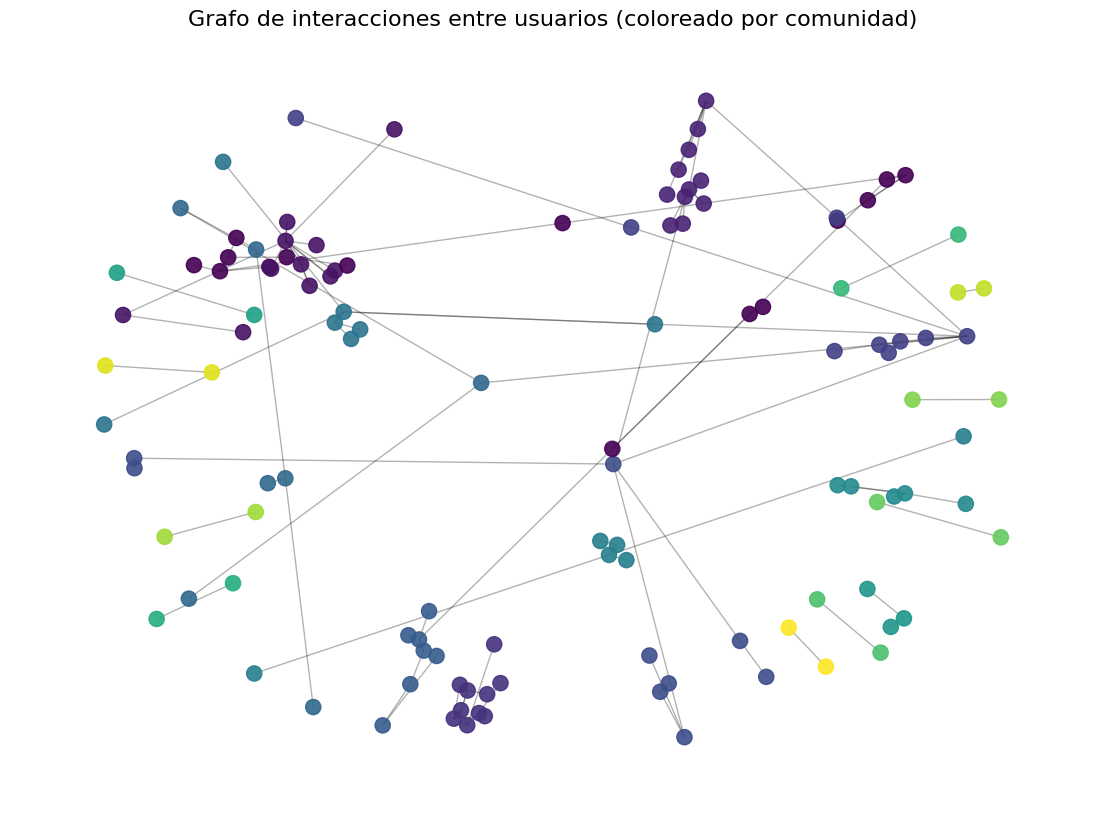

In [32]:
pos = nx.spring_layout(G, seed=42)
#Mapa de colores
node_colors = [G.nodes[n]["community"] for n in G.nodes()]

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(
    G, pos,
    node_size=120,
    node_color=node_colors,
    cmap="viridis",
    alpha=0.9
)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=False)

plt.title("Grafo de interacciones entre usuarios (coloreado por comunidad)", fontsize=16)
plt.axis("off")
plt.show()

/tmp/ipython-input-2600522684.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(communities_ids))


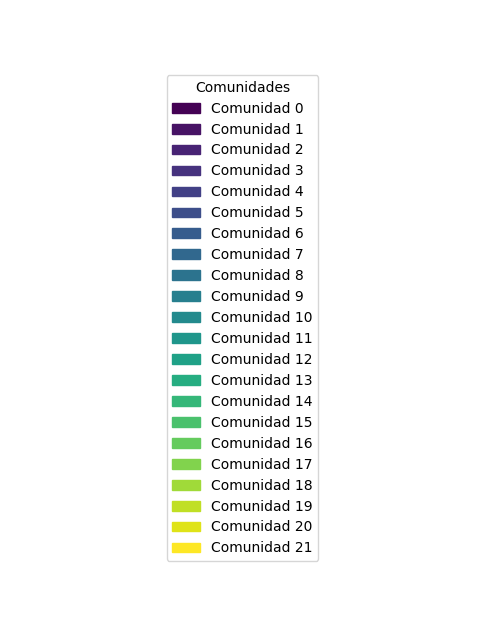

In [33]:
#Obt IDs únicos de comunidades
communities_ids = sorted(set(community_map.values()))

#Obt color desde el colormap viridis
cmap = cm.get_cmap("viridis", len(communities_ids))
community_to_color = {cid: cmap(i) for i, cid in enumerate(communities_ids)}

#Dibujar la leyenda
legend_handles = [
    mpatches.Patch(color=community_to_color[cid], label=f"Comunidad {cid}")
    for cid in communities_ids
]

plt.figure(figsize=(6, 8))
plt.legend(handles=legend_handles, title="Comunidades", loc="center")
plt.axis("off")
plt.show()

In [34]:
#Asegurar que los nodos tengan el atributo "sentiment"
#(basado en df que contiene comment_author y sentiment_score)

sent_mean = df.groupby("comment_author")["sentiment_score"].mean().to_dict()

for node in G.nodes():
    if node in sent_mean:
        G.nodes[node]["sentiment"] = sent_mean[node]

community_sent = {}

for node, data in G.nodes(data=True):
    cid = data.get("community")
    s = data.get("sentiment")
    if cid is not None and s is not None:
        community_sent.setdefault(cid, []).append(s)

sent_df = pd.DataFrame([
    {
        "community": cid,
        "sentiment_mean": np.mean(vals),
        "n_users": len(vals)
    }
    for cid, vals in community_sent.items()
])

display(sent_df)

,community,sentiment_mean,n_users
0,4,-0.518519,9
1,5,-0.198413,9
2,3,-0.216667,10
3,2,-0.266234,11
4,8,-0.342857,7
...,...,...,...
17,17,-1.000000,2
18,18,-1.000000,2
19,19,-1.000000,2
20,20,-1.000000,2


In [35]:
sent_df_sorted = sent_df.sort_values("sentiment_mean")
sent_df_sorted

,community,sentiment_mean,n_users
20,20,-1.000000,2
19,19,-1.000000,2
18,18,-1.000000,2
17,17,-1.000000,2
12,10,-0.866667,5
...,...,...,...
1,5,-0.198413,9
5,0,-0.193333,15
9,9,-0.041667,6
14,15,0.500000,2


In [36]:
def classify_group(score):
    if score <= -0.6:
        return "Comunidad muy negativa"
    elif score <= -0.2:
        return "Comunidad negativa"
    elif score < 0.2:
        return "Comunidad neutra"
    elif score < 0.6:
        return "Comunidad positiva"
    else:
        return "Comunidad muy positiva"

sent_df_sorted["grupo_sentimiento"] = sent_df_sorted["sentiment_mean"].apply(classify_group)
sent_df_sorted

,community,sentiment_mean,n_users,grupo_sentimiento
20,20,-1.000000,2,Comunidad muy negativa
19,19,-1.000000,2,Comunidad muy negativa
18,18,-1.000000,2,Comunidad muy negativa
17,17,-1.000000,2,Comunidad muy negativa
12,10,-0.866667,5,Comunidad muy negativa
...,...,...,...,...
1,5,-0.198413,9,Comunidad neutra
5,0,-0.193333,15,Comunidad neutra
9,9,-0.041667,6,Comunidad neutra
14,15,0.500000,2,Comunidad positiva


In [37]:
for _, row in sent_df_sorted.iterrows():
    print(
        f"Comunidad {row['community']:>2} → {row['grupo_sentimiento']} "
        f"(sentimiento medio = {row['sentiment_mean']:.2f}, usuarios = {row['n_users']})"
    )

Comunidad 20 → Comunidad muy negativa (sentimiento medio = -1.00, usuarios = 2)
Comunidad 19 → Comunidad muy negativa (sentimiento medio = -1.00, usuarios = 2)
Comunidad 18 → Comunidad muy negativa (sentimiento medio = -1.00, usuarios = 2)
Comunidad 17 → Comunidad muy negativa (sentimiento medio = -1.00, usuarios = 2)
Comunidad 10 → Comunidad muy negativa (sentimiento medio = -0.87, usuarios = 5)
Comunidad  6 → Comunidad muy negativa (sentimiento medio = -0.79, usuarios = 7)
Comunidad 16 → Comunidad muy negativa (sentimiento medio = -0.75, usuarios = 2)
Comunidad 11 → Comunidad muy negativa (sentimiento medio = -0.67, usuarios = 3)
Comunidad 13 → Comunidad muy negativa (sentimiento medio = -0.67, usuarios = 2)
Comunidad  1 → Comunidad negativa (sentimiento medio = -0.53, usuarios = 11)
Comunidad  4 → Comunidad negativa (sentimiento medio = -0.52, usuarios = 9)
Comunidad  7 → Comunidad negativa (sentimiento medio = -0.50, usuarios = 7)
Comunidad 21 → Comunidad negativa (sentimiento medi

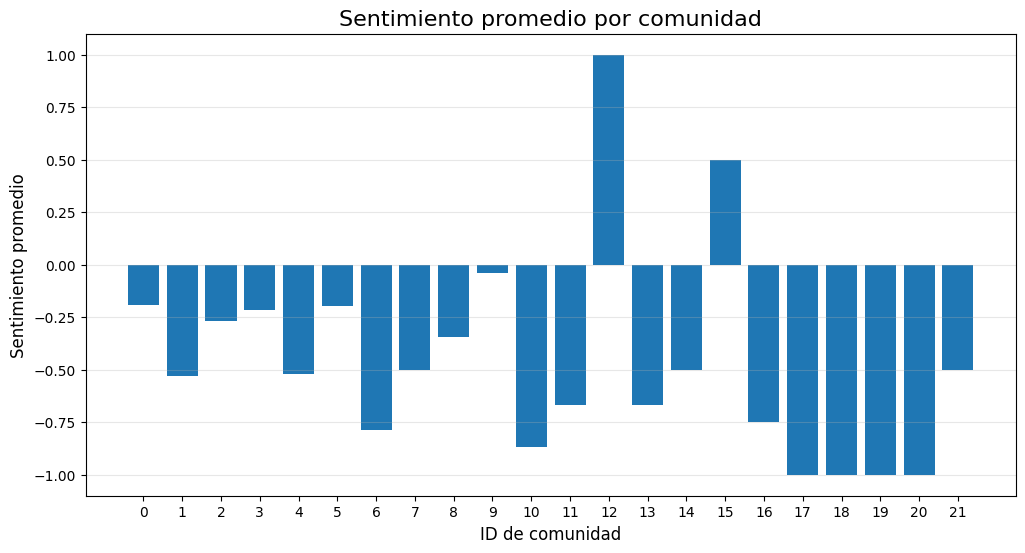

In [38]:
plt.figure(figsize=(12, 6))
plt.bar(sent_df_sorted["community"], sent_df_sorted["sentiment_mean"])
plt.xlabel("ID de comunidad", fontsize=12)
plt.ylabel("Sentimiento promedio", fontsize=12)
plt.title("Sentimiento promedio por comunidad", fontsize=16)
plt.xticks(sent_df_sorted["community"])
plt.grid(axis="y", alpha=0.3)
plt.show()

In [39]:
#1) Sentimiento promedio por usuario a partir del DataFrame df
sent_mean = (
    df.groupby("comment_author")["sentiment_score"]
      .mean()
      .to_dict()
)

#2) Asignar ese sentimiento a cada nodo del grafo (si existe en el mapping)
for node in G.nodes():
    if node in sent_mean:
        G.nodes[node]["sentiment"] = float(sent_mean[node])

In [40]:
#Crear grafo no dirigido para detectar comunidades
G_und = G.to_undirected()

#Det comunidades con modularidad (greedy)
communities = list(nx.community.greedy_modularity_communities(G_und))

#Asignar ID de comunidad a cada nodo
community_map = {}
for cid, comm in enumerate(communities):
    for node in comm:
        community_map[node] = cid

nx.set_node_attributes(G, community_map, "community")

print(f"Comunidades detectadas: {len(communities)}")

Comunidades detectadas: 22


In [41]:
#IDs de comunidades existentes
communities_ids = sorted(set(community_map.values()))

#Mapa de colores usando el colormap 'viridis'
cmap = cm.get_cmap("viridis", len(communities_ids))
community_to_color = {
    cid: cmap(i) for i, cid in enumerate(communities_ids)
}

community_to_color  #para ver el mapping

/tmp/ipython-input-3859385911.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(communities_ids))


{0: (np.float64(0.267004),
  np.float64(0.004874),
  np.float64(0.329415),
  np.float64(1.0)),
 1: (np.float64(0.280267),
  np.float64(0.073417),
  np.float64(0.397163),
  np.float64(1.0)),
 2: (np.float64(0.282884),
  np.float64(0.13592),
  np.float64(0.453427),
  np.float64(1.0)),
 3: (np.float64(0.275191),
  np.float64(0.194905),
  np.float64(0.496005),
  np.float64(1.0)),
 4: (np.float64(0.258965),
  np.float64(0.251537),
  np.float64(0.524736),
  np.float64(1.0)),
 5: (np.float64(0.237441),
  np.float64(0.305202),
  np.float64(0.541921),
  np.float64(1.0)),
 6: (np.float64(0.212395),
  np.float64(0.359683),
  np.float64(0.55171),
  np.float64(1.0)),
 7: (np.float64(0.190631),
  np.float64(0.407061),
  np.float64(0.556089),
  np.float64(1.0)),
 8: (np.float64(0.171176),
  np.float64(0.45253),
  np.float64(0.557965),
  np.float64(1.0)),
 9: (np.float64(0.153364),
  np.float64(0.497),
  np.float64(0.557724),
  np.float64(1.0)),
 10: (np.float64(0.136408),
  np.float64(0.541173),
  np

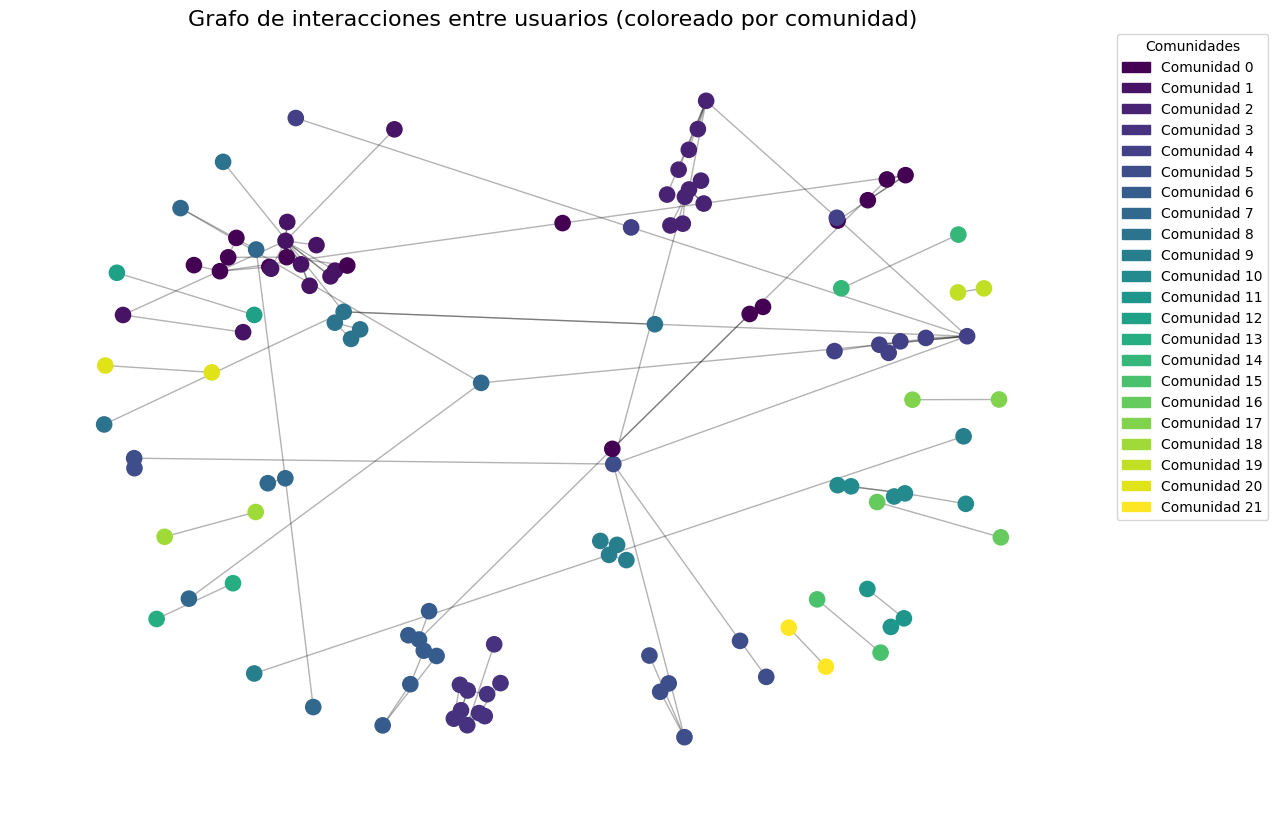

In [42]:
#Layout del grafo
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(14, 10))

#Colores de cada nodo según su comunidad
node_colors = [
    community_to_color[G.nodes[n]["community"]]
    for n in G.nodes()
]

#Dibujar nodos y aristas
nx.draw_networkx_nodes(
    G, pos,
    node_size=120,
    node_color=node_colors,
    ax=ax
)
nx.draw_networkx_edges(
    G, pos,
    alpha=0.3,
    arrows=False,
    ax=ax
)

ax.set_title("Grafo de interacciones entre usuarios (coloreado por comunidad)", fontsize=16)
ax.set_axis_off()

#Construir leyenda: qué color corresponde a qué comunidad
legend_handles = [
    mpatches.Patch(color=community_to_color[cid], label=f"Comunidad {cid}")
    for cid in communities_ids
]

ax.legend(
    handles=legend_handles,
    title="Comunidades",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),  # fuera de la figura
    borderaxespad=0.
)

plt.show() #grafo más completo que el anterior

In [43]:
#Construir lista de sentimientos por comunidad
community_sent = {}

for node, data in G.nodes(data=True):
    cid = data.get("community")
    s = data.get("sentiment")
    if cid is not None and s is not None:
        community_sent.setdefault(cid, []).append(s)

#DataFrame con promedio y tamaño
sent_df = pd.DataFrame([
    {
        "community": cid,
        "sentiment_mean": np.mean(vals),
        "n_users": len(vals)
    }
    for cid, vals in community_sent.items()
])

#Ordenar de más negativa a más positiva
sent_df_sorted = sent_df.sort_values("sentiment_mean")
sent_df_sorted

,community,sentiment_mean,n_users
20,20,-1.000000,2
19,19,-1.000000,2
18,18,-1.000000,2
17,17,-1.000000,2
12,10,-0.866667,5
...,...,...,...
1,5,-0.198413,9
5,0,-0.193333,15
9,9,-0.041667,6
14,15,0.500000,2


In [44]:
#Construir lista de sentimientos por comunidad desde el grafo
community_sent = {}

for node, data in G.nodes(data=True):
    cid = data.get("community")
    s = data.get("sentiment")
    if cid is not None and s is not None:
        community_sent.setdefault(cid, []).append(s)

sent_df_sorted = pd.DataFrame([
    {
        "community": cid,
        "sentiment_mean": np.mean(vals),
        "n_users": len(vals)
    }
    for cid, vals in community_sent.items()
]).sort_values("community").reset_index(drop=True)

def classify_group(score):
    if score <= -0.6:
        return "muy negativa"
    elif score <= -0.2:
        return "negativa"
    elif score < 0.2:
        return "neutra"
    elif score < 0.6:
        return "positiva"
    else:
        return "muy positiva"

sent_df_sorted["grupo_sentimiento"] = sent_df_sorted["sentiment_mean"].apply(classify_group)
sent_df_sorted

,community,sentiment_mean,n_users,grupo_sentimiento
0,0,-0.193333,15,neutra
1,1,-0.530303,11,negativa
2,2,-0.266234,11,negativa
3,3,-0.216667,10,negativa
4,4,-0.518519,9,negativa
...,...,...,...,...
17,17,-1.000000,2,muy negativa
18,18,-1.000000,2,muy negativa
19,19,-1.000000,2,muy negativa
20,20,-1.000000,2,muy negativa


In [45]:
#Paleta manual por grupo (colores muy distintos)
grupo_to_color = {
    "muy negativa": "#d73027",   #rojo fuerte
    "negativa":     "#fc8d59",   #naranja
    "neutra":       "#cccccc",   #gris
    "positiva":     "#91cf60",   #verde claro
    "muy positiva": "#1a9850",   #verde oscuro
}

#Mapa comunidad -> grupo
community_to_group = dict(zip(sent_df_sorted["community"], sent_df_sorted["grupo_sentimiento"]))

#Mapa comunidad -> color
community_to_color = {
    cid: grupo_to_color[community_to_group[cid]]
    for cid in community_to_group.keys()
}

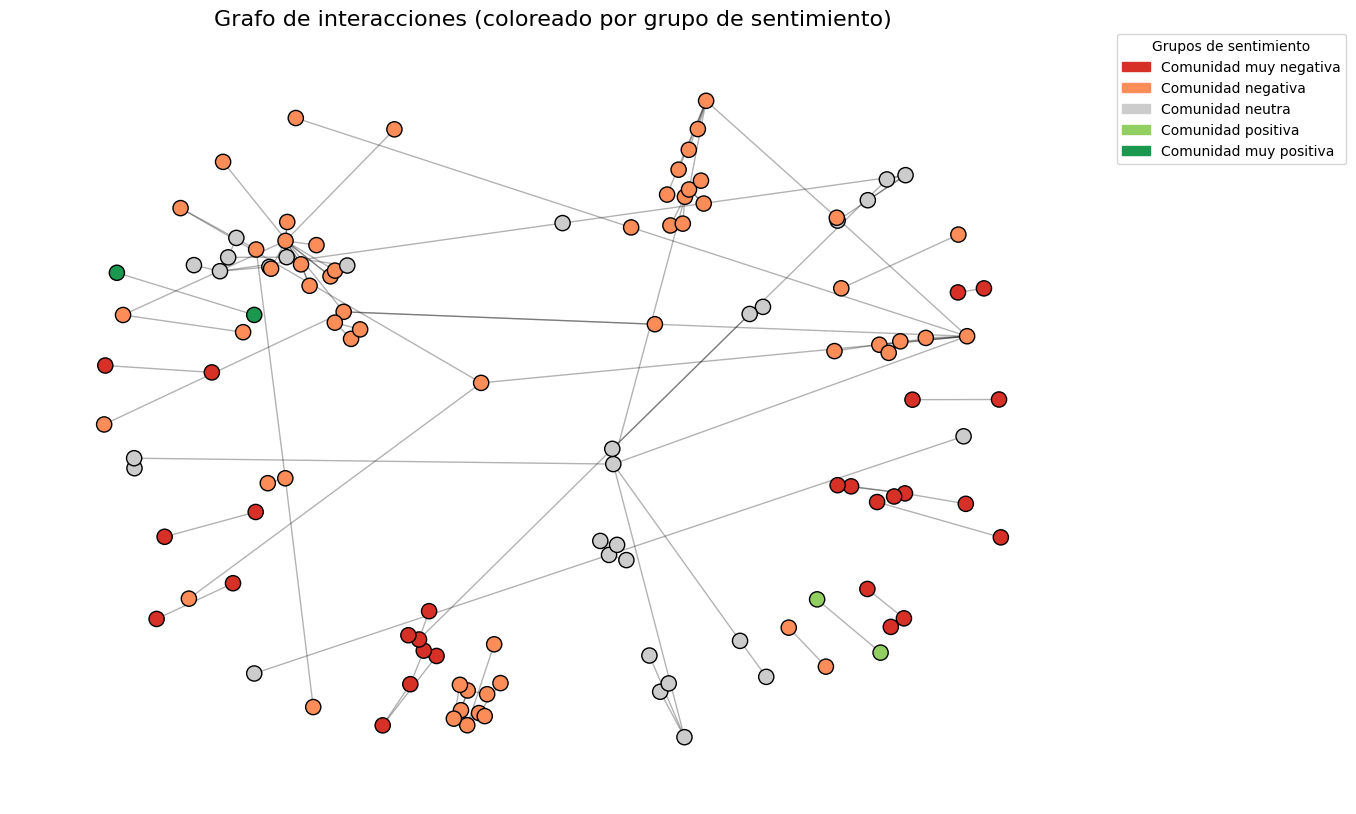

In [46]:
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(14, 10))

#Color de cada nodo según el grupo de sentimiento de su comunidad
node_colors = [
    community_to_color[G.nodes[n]["community"]]
    for n in G.nodes()
]

nx.draw_networkx_nodes(
    G, pos,
    node_size=120,
    node_color=node_colors,
    ax=ax,
    edgecolors="black"  #bordes negros para que destaquen más
)
nx.draw_networkx_edges(
    G, pos,
    alpha=0.3,
    arrows=False,
    ax=ax
)

ax.set_title("Grafo de interacciones (coloreado por grupo de sentimiento)", fontsize=16)
ax.set_axis_off()

#Leyenda por grupo de sentimiento (no por comunidad individual)
legend_handles = [
    mpatches.Patch(color=color, label=f"Comunidad {grupo}")
    for grupo, color in grupo_to_color.items()
]
ax.legend(
    handles=legend_handles,
    title="Grupos de sentimiento",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.
)

plt.show() #grafo final, más completo y con mayor distinción e identificación de comunidades, en comparación a los anteriores generados

In [47]:
sent_df_sorted[["community", "sentiment_mean", "grupo_sentimiento"]]

,community,sentiment_mean,grupo_sentimiento
0,0,-0.193333,neutra
1,1,-0.530303,negativa
2,2,-0.266234,negativa
3,3,-0.216667,negativa
4,4,-0.518519,negativa
...,...,...,...
17,17,-1.000000,muy negativa
18,18,-1.000000,muy negativa
19,19,-1.000000,muy negativa
20,20,-1.000000,muy negativa


---

## Preguntas orientadoras:

---

• **¿Qué tan polarizada está la conversación?**

La conversación muestra más bien un consenso negativo que una polarización clásica en dos polos equivalentes. La polarización se da entre una mayoría de comunidades muy críticas y un puñado de comunidades que mantienen un tono neutro o incluso positivo, pero estas últimas son minoritarias y poco influyentes.

---

• **¿Existen comunidades que actúan como puentes entre grupos ideológicos
opuestos?**

Sí, parecen existir “comunidades puente”: grupos con tono más moderado (neutro o levemente negativo) que se ubican estructuralmente cerca del centro del grafo y conectan usuarios de comunidades muy negativas con otros más neutrales o incluso positivos. Estas comunidades no son las más grandes, pero su posición les permite canalizar información entre grupos con posturas emocionales distintas.

---

• **¿Qué rol tienen los nodos más influyentes en la propagación de posturas extremas o conciliadoras?**

Los nodos más influyentes de la red (mayor grado) pertenecen en su mayoría a comunidades negativas o muy negativas, por lo que contribuyen a amplificar y consolidar un discurso crítico respecto al apagón.
En cambio, los nodos de comunidades positivas o muy positivas tienden a ser poco centrales y a estar ubicados en ramales periféricos, por lo que su rol en la propagación de mensajes conciliadores es reducido. Esto sugiere que, en esta conversación, la estructura de la red favorece la difusión del descontento por sobre las narrativas más moderadas o justificadoras.

---

## 2.1 Propagación de opiniones (modelo de dinámica de opinión)

In [48]:
#Asegurar que cada nodo tenga una opinión inicial (sentiment promedio del usuario)
sent_mean = df.groupby("comment_author")["sentiment_score"].mean().to_dict()

for node in G.nodes():
    G.nodes[node]["opinion_0"] = float(sent_mean.get(node, 0.0))  # 0 si no lo encontramos

#Diccionario de opiniones iniciales x_i(0)
opinions_0 = {node: G.nodes[node]["opinion_0"] for node in G.nodes()}

#Chequear rango
vals = np.array(list(opinions_0.values()))
print("Opinión mínima:", vals.min(), "máxima:", vals.max())
print("Promedio inicial:", vals.mean())

Opinión mínima: -1.0 máxima: 1.0
Promedio inicial: -0.400813492063492


In [49]:
#Grafo no dirigido para el modelo de opinión
G_op = G.to_undirected()

def degroot_step(G, opinions, alpha=0.4):
    """
    Una iteración del modelo DeGroot sobre el grafo G
    - G: grafo (usamos no dirigido)
    - opinions: dict {nodo: opinion_actual}
    - alpha: peso de la opinión propia
    Devuelve: nuevo dict {nodo: opinion_actualizada}
    """
    new_opinions = {}

    for node in G.nodes():
        x_i = opinions[node]
        neighbors = list(G.neighbors(node))

        if not neighbors:
            # Sin vecinos: mantiene su opinión
            new_opinions[node] = x_i
            continue

        neigh_vals = [opinions[n] for n in neighbors]
        mean_neigh = float(np.mean(neigh_vals))

        new_opinions[node] = alpha * x_i + (1 - alpha) * mean_neigh

    return new_opinions

In [50]:
def simulate_degroot(G, opinions_0, T=30, alpha=0.4):
    """
    Simula el modelo DeGroot T pasos
    Devuelve:
    - history: lista de dicts de opiniones [{nodo: opinion_en_t}, ...]
    - stats_df: DataFrame con estadísticos globales por tiempo.
    """
    history = []
    stats = []

    opinions = opinions_0.copy()

    for t in range(T + 1):
        # Guardamos snapshot
        history.append(opinions.copy())

        vals = np.array(list(opinions.values()))
        stats.append({
            "t": t,
            "mean": float(vals.mean()),
            "std": float(vals.std()),
            "min": float(vals.min()),
            "max": float(vals.max()),
        })

        #No actualizar en el último paso
        if t == T:
            break

        opinions = degroot_step(G, opinions, alpha=alpha)

    stats_df = pd.DataFrame(stats)
    return history, stats_df

history, stats_df = simulate_degroot(G_op, opinions_0, T=30, alpha=0.4)

stats_df.head()

,t,mean,std,min,max
0,0,-0.400813,0.589119,-1.0,1.0
1,1,-0.438692,0.419022,-1.0,1.0
2,2,-0.436993,0.385230,-1.0,1.0
3,3,-0.437879,0.370147,-1.0,1.0
4,4,-0.438416,0.360276,-1.0,1.0


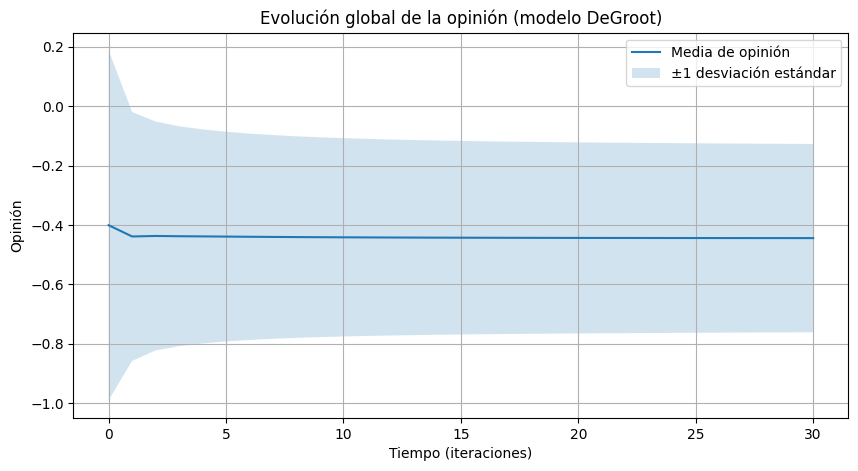

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(stats_df["t"], stats_df["mean"], label="Media de opinión")
plt.fill_between(
    stats_df["t"],
    stats_df["mean"] - stats_df["std"],
    stats_df["mean"] + stats_df["std"],
    alpha=0.2,
    label="±1 desviación estándar"
)
plt.xlabel("Tiempo (iteraciones)")
plt.ylabel("Opinión")
plt.title("Evolución global de la opinión (modelo DeGroot)")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
#Opiniones finales después de la simulación
opinions_final = history[-1]  # último dict

#Construir DataFrame nodos-comunidad-opinión_final
nodes_data = []
for node, data in G.nodes(data=True):
    cid = data.get("community")
    op0 = data.get("opinion_0")
    opT = opinions_final.get(node, np.nan)
    nodes_data.append({
        "user": node,
        "community": cid,
        "opinion_0": op0,
        "opinion_T": opT,
    })

df_dyn = pd.DataFrame(nodes_data).dropna(subset=["community", "opinion_T"])

#Promedio por comunidad, antes y después
community_dyn = (
    df_dyn.groupby("community")[["opinion_0", "opinion_T"]]
          .mean()
          .sort_values("opinion_0")
)

community_dyn

,opinion_0,opinion_T
community,,
20,-1.000000,-1.000000
19,-1.000000,-1.000000
18,-1.000000,-1.000000
17,-1.000000,-1.000000
10,-0.866667,-0.791667
...,...,...
5,-0.198413,-0.416746
0,-0.193333,-0.271351
9,-0.041667,-0.099999


## 2.2 Simulaciones con diferentes parámetros de tolerancia o influencia.

In [53]:
#Diferentes niveles de "influencia" (1 - alpha)
alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]
T = 30  #núm de iteraciones

results_stats = {}   #alpha -> stats_df
results_history = {} #alpha -> history

for alpha in alpha_values:
    print(f"Simulando DeGroot con alpha = {alpha}...")
    history_alpha, stats_alpha = simulate_degroot(G_op, opinions_0, T=T, alpha=alpha)
    results_stats[alpha] = stats_alpha
    results_history[alpha] = history_alpha

Simulando DeGroot con alpha = 0.1...
Simulando DeGroot con alpha = 0.3...
Simulando DeGroot con alpha = 0.5...
Simulando DeGroot con alpha = 0.7...
Simulando DeGroot con alpha = 0.9...


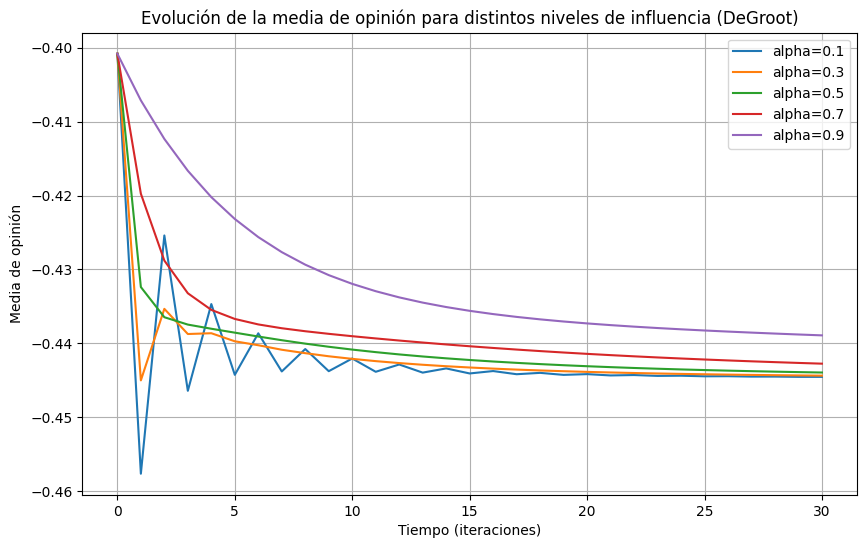

In [54]:
plt.figure(figsize=(10, 6))

for alpha, stats_df_alpha in results_stats.items():
    plt.plot(stats_df_alpha["t"], stats_df_alpha["mean"], label=f"alpha={alpha}")

plt.xlabel("Tiempo (iteraciones)")
plt.ylabel("Media de opinión")
plt.title("Evolución de la media de opinión para distintos niveles de influencia (DeGroot)")
plt.grid(True)
plt.legend()
plt.show()

In [55]:
summary_rows = []

for alpha, stats_df_alpha in results_stats.items():
    last_row = stats_df_alpha.iloc[-1]
    summary_rows.append({
        "alpha": alpha,
        "mean_final": last_row["mean"],
        "std_final": last_row["std"],
        "min_final": last_row["min"],
        "max_final": last_row["max"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("alpha")
summary_df

,alpha,mean_final,std_final,min_final,max_final
0,0.1,-0.444531,0.313448,-1.0,1.0
1,0.3,-0.444365,0.315551,-1.0,1.0
2,0.5,-0.443940,0.318963,-1.0,1.0
3,0.7,-0.442743,0.326148,-1.0,1.0
4,0.9,-0.438915,0.354929,-1.0,1.0


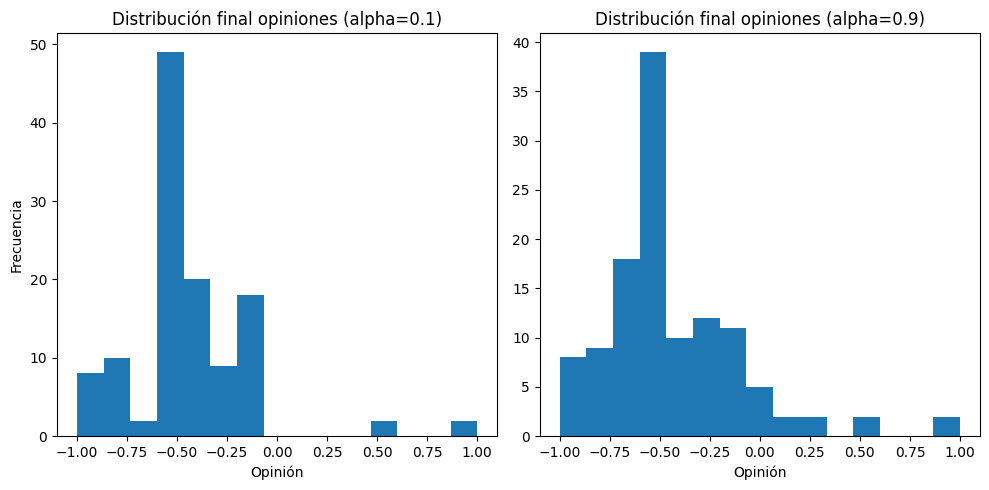

In [56]:
alpha_low = 0.1
alpha_high = 0.9

opinions_final_low = np.array(list(results_history[alpha_low][-1].values()))
opinions_final_high = np.array(list(results_history[alpha_high][-1].values()))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(opinions_final_low, bins=15)
plt.title(f"Distribución final opiniones (alpha={alpha_low})")
plt.xlabel("Opinión")
plt.ylabel("Frecuencia")

plt.subplot(1, 2, 2)
plt.hist(opinions_final_high, bins=15)
plt.title(f"Distribución final opiniones (alpha={alpha_high})")
plt.xlabel("Opinión")

plt.tight_layout()
plt.show()

## 2.3 Evolución distribución de opiniones.

In [57]:
#Elegimos un escenario base para analizar la dinámica
alpha_base = 0.3
T = 30

history_base, stats_base = simulate_degroot(G_op, opinions_0, T=T, alpha=alpha_base)

stats_base.head()

,t,mean,std,min,max
0,0,-0.400813,0.589119,-1.0,1.0
1,1,-0.445006,0.418986,-1.0,1.0
2,2,-0.435328,0.378651,-1.0,1.0
3,3,-0.438733,0.364517,-1.0,1.0
4,4,-0.438626,0.354820,-1.0,1.0


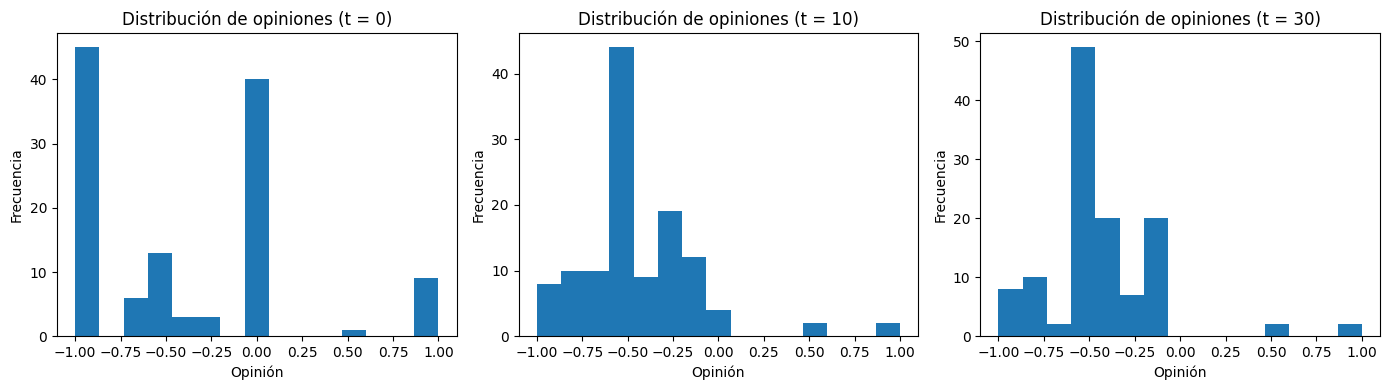

In [58]:
#Tiempos que vamos a mirar
times = [0, 10, 30]  #inicio, medio, final

plt.figure(figsize=(14, 4))

for i, t in enumerate(times, start=1):
    opinions_t = np.array(list(history_base[t].values()))

    plt.subplot(1, len(times), i)
    plt.hist(opinions_t, bins=15)
    plt.title(f"Distribución de opiniones (t = {t})")
    plt.xlabel("Opinión")
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [59]:
def classify_opinion(x, thr=0.2):
    if x <= -thr:
        return "negativa"
    elif x >= thr:
        return "positiva"
    else:
        return "neutra"

rows = []

for t in range(T + 1):
    opinions_t = np.array(list(history_base[t].values()))
    labels = [classify_opinion(x) for x in opinions_t]
    s = pd.Series(labels).value_counts(normalize=True)
    rows.append({
        "t": t,
        "negativa": s.get("negativa", 0.0),
        "neutra":   s.get("neutra", 0.0),
        "positiva": s.get("positiva", 0.0),
    })

dist_time_df = pd.DataFrame(rows)
dist_time_df.head()

,t,negativa,neutra,positiva
0,0,0.583333,0.333333,0.083333
1,1,0.775000,0.141667,0.083333
2,2,0.783333,0.141667,0.075000
3,3,0.783333,0.150000,0.066667
4,4,0.800000,0.150000,0.050000


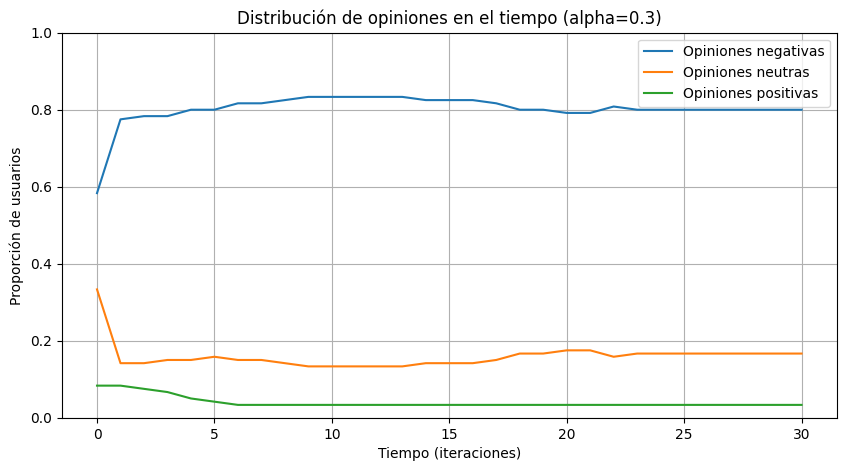

In [60]:
plt.figure(figsize=(10, 5))
plt.plot(dist_time_df["t"], dist_time_df["negativa"], label="Opiniones negativas")
plt.plot(dist_time_df["t"], dist_time_df["neutra"],   label="Opiniones neutras")
plt.plot(dist_time_df["t"], dist_time_df["positiva"], label="Opiniones positivas")

plt.xlabel("Tiempo (iteraciones)")
plt.ylabel("Proporción de usuarios")
plt.title(f"Distribución de opiniones en el tiempo (alpha={alpha_base})")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [61]:
#Asegurarnos de que cada nodo tiene atributo 'community'
communities_ids = sorted({data["community"] for _, data in G.nodes(data=True)})

rows = []

for t in range(T + 1):
    opinions_t = history_base[t]

    #opinión media de cada comunidad en este tiempo
    comm_means = []
    for cid in communities_ids:
        nodes_c = [n for n, d in G.nodes(data=True) if d["community"] == cid]
        vals_c = [opinions_t[n] for n in nodes_c if n in opinions_t]
        if len(vals_c) > 0:
            comm_means.append(np.mean(vals_c))

    #dispersión entre comunidades (std de las medias)
    if len(comm_means) > 0:
        comm_means = np.array(comm_means)
        rows.append({
            "t": t,
            "mean_over_communities": float(comm_means.mean()),
            "std_between_communities": float(comm_means.std()),
            "min_comm": float(comm_means.min()),
            "max_comm": float(comm_means.max()),
        })

comm_dyn_df = pd.DataFrame(rows)
comm_dyn_df.head()

,t,mean_over_communities,std_between_communities,min_comm,max_comm
0,0,-0.456532,0.481405,-1.0,1.0
1,1,-0.482457,0.478357,-1.0,1.0
2,2,-0.475864,0.476642,-1.0,1.0
3,3,-0.477807,0.475481,-1.0,1.0
4,4,-0.477418,0.474704,-1.0,1.0


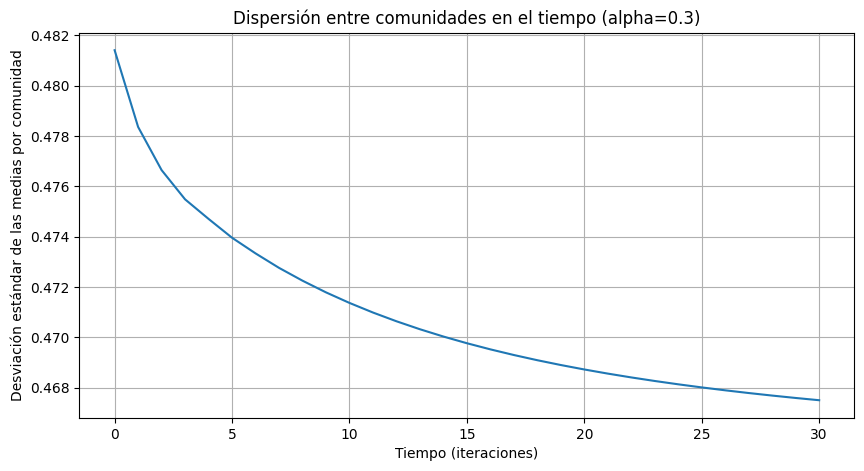

In [62]:
plt.figure(figsize=(10, 5))
plt.plot(comm_dyn_df["t"], comm_dyn_df["std_between_communities"])
plt.xlabel("Tiempo (iteraciones)")
plt.ylabel("Desviación estándar de las medias por comunidad")
plt.title(f"Dispersión entre comunidades en el tiempo (alpha={alpha_base})")
plt.grid(True)
plt.show()

 ## 2.4 Simulación de intervención o censura

In [63]:
#Construimos de nuevo el resumen de sentimiento por comunidad desde el grafo
community_sent = {}

for node, data in G.nodes(data=True):
    cid = data.get("community")
    s = data.get("sentiment")
    if cid is not None and s is not None:
        community_sent.setdefault(cid, []).append(s)

sent_df = pd.DataFrame([
    {
        "community": cid,
        "sentiment_mean": np.mean(vals),
        "n_users": len(vals)
    }
    for cid, vals in community_sent.items()
])

#Ordenamos por sentimiento
sent_df_sorted = sent_df.sort_values("sentiment_mean").reset_index(drop=True)
sent_df_sorted

,community,sentiment_mean,n_users
0,20,-1.000000,2
1,19,-1.000000,2
2,18,-1.000000,2
3,17,-1.000000,2
4,10,-0.866667,5
...,...,...,...
17,5,-0.198413,9
18,0,-0.193333,15
19,9,-0.041667,6
20,15,0.500000,2


In [64]:
#Grafo base (no dirigido) sobre el que ya corriste DeGroot
G_base = G.to_undirected()

#2.1 Grafo "eco": eliminar aristas entre comunidades distintas
G_echo = G_base.copy()

edges_to_remove = []
for u, v in G_echo.edges():
    cu = G.nodes[u]["community"]
    cv = G.nodes[v]["community"]
    if cu != cv:
        edges_to_remove.append((u, v))

G_echo.remove_edges_from(edges_to_remove)

print("Aristas eliminadas (inter-comunidades):", len(edges_to_remove))
print("Grafo eco - nodos:", G_echo.number_of_nodes(), "aristas:", G_echo.number_of_edges())

#2.2 Grafo "puentes": reforzar conexiones entre comunidades opuestas

#Def comunidades muy negativas y (muy) positivas
neg_comms = sent_df_sorted[sent_df_sorted["sentiment_mean"] <= -0.6]["community"].tolist()
pos_comms = sent_df_sorted[sent_df_sorted["sentiment_mean"] >= 0.2]["community"].tolist()

neg_nodes = [n for n, d in G.nodes(data=True) if d["community"] in neg_comms]
pos_nodes = [n for n, d in G.nodes(data=True) if d["community"] in pos_comms]

print("Comunidades muy negativas:", neg_comms)
print("Comunidades positivas/muy positivas:", pos_comms)
print("Nodos muy negativos:", len(neg_nodes), " | Nodos positivos:", len(pos_nodes))

G_bridge = G_base.copy()

#Núm de puentes que queremos añadir
n_bridges = min(30, len(neg_nodes) * len(pos_nodes))

added = 0
attempts = 0
max_attempts = 200

while added < n_bridges and attempts < max_attempts and neg_nodes and pos_nodes:
    u = random.choice(neg_nodes)
    v = random.choice(pos_nodes)
    attempts += 1

    if u == v:
        continue
    if G_bridge.has_edge(u, v):
        continue

    G_bridge.add_edge(u, v)
    added += 1

print("Puentes añadidos entre grupos opuestos:", added)
print("Grafo puente - nodos:", G_bridge.number_of_nodes(), "aristas:", G_bridge.number_of_edges())

Aristas eliminadas (inter-comunidades): 6
Grafo eco - nodos: 120 aristas: 100
Comunidades muy negativas: [20, 19, 18, 17, 10, 6, 16, 11, 13]
Comunidades positivas/muy positivas: [15, 12]
Nodos muy negativos: 27  | Nodos positivos: 4
Puentes añadidos entre grupos opuestos: 30
Grafo puente - nodos: 120 aristas: 136


In [65]:
alpha_base = 0.3
T = 30

#Escenario original
history_base, stats_base = simulate_degroot(G_base, opinions_0, T=T, alpha=alpha_base)

#Escenario eco (sin conexiones entre comunidades)
history_echo, stats_echo = simulate_degroot(G_echo, opinions_0, T=T, alpha=alpha_base)

#Escenario con puentes entre comunidades opuestas
history_bridge, stats_bridge = simulate_degroot(G_bridge, opinions_0, T=T, alpha=alpha_base)

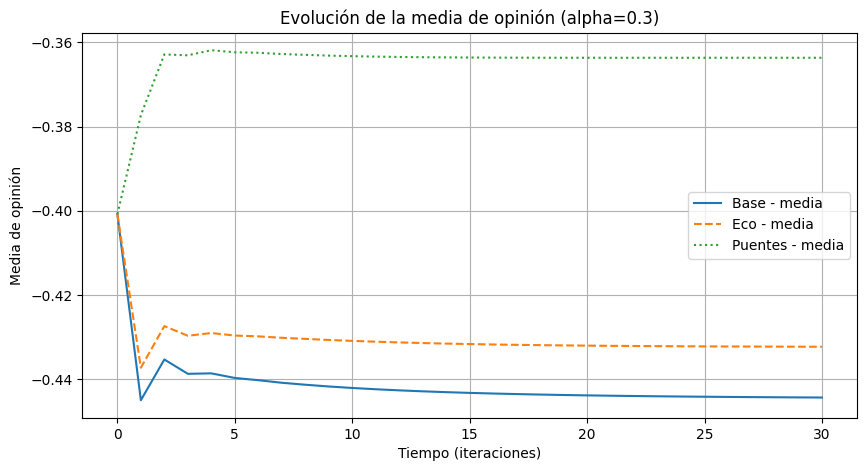

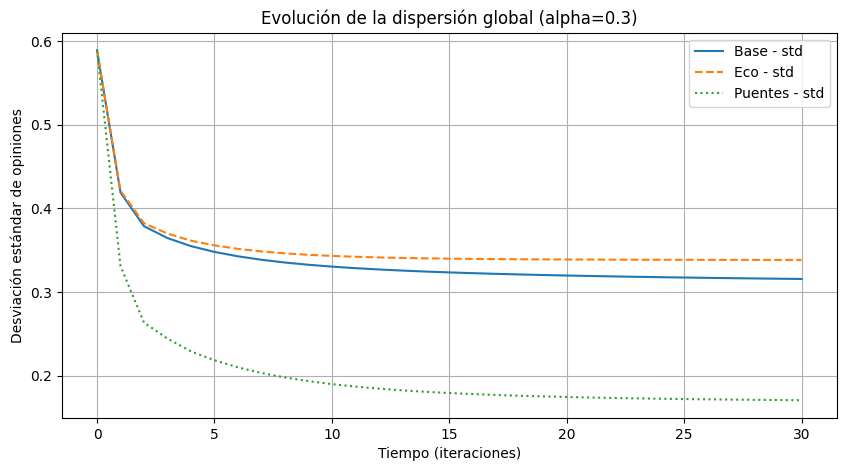

In [66]:
plt.figure(figsize=(10, 5))

plt.plot(stats_base["t"], stats_base["mean"],   label="Base - media")
plt.plot(stats_echo["t"], stats_echo["mean"],   label="Eco - media", linestyle="--")
plt.plot(stats_bridge["t"], stats_bridge["mean"], label="Puentes - media", linestyle=":")

plt.xlabel("Tiempo (iteraciones)")
plt.ylabel("Media de opinión")
plt.title(f"Evolución de la media de opinión (alpha={alpha_base})")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(stats_base["t"], stats_base["std"],   label="Base - std")
plt.plot(stats_echo["t"], stats_echo["std"],   label="Eco - std", linestyle="--")
plt.plot(stats_bridge["t"], stats_bridge["std"], label="Puentes - std", linestyle=":")

plt.xlabel("Tiempo (iteraciones)")
plt.ylabel("Desviación estándar de opiniones")
plt.title(f"Evolución de la dispersión global (alpha={alpha_base})")
plt.grid(True)
plt.legend()
plt.show()

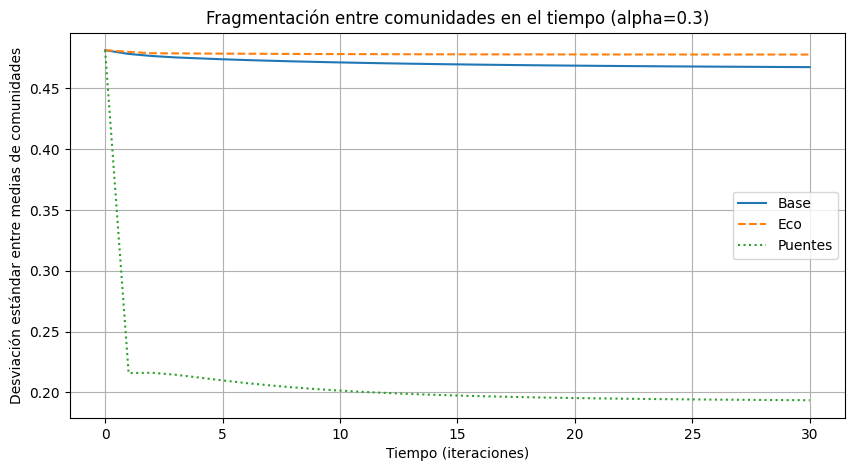

In [67]:
def community_dispersion_over_time(G_ref, history):
    rows = []
    communities_ids = sorted({d["community"] for _, d in G.nodes(data=True)})

    for t in range(len(history)):
        opinions_t = history[t]
        comm_means = []

        for cid in communities_ids:
            nodes_c = [n for n, d in G.nodes(data=True) if d["community"] == cid]
            vals_c = [opinions_t[n] for n in nodes_c if n in opinions_t]
            if vals_c:
                comm_means.append(np.mean(vals_c))

        comm_means = np.array(comm_means)
        rows.append({
            "t": t,
            "std_between_communities": float(comm_means.std())
        })

    return pd.DataFrame(rows)

comm_base   = community_dispersion_over_time(G_base,   history_base)
comm_echo   = community_dispersion_over_time(G_echo,   history_echo)
comm_bridge = community_dispersion_over_time(G_bridge, history_bridge)

plt.figure(figsize=(10, 5))
plt.plot(comm_base["t"],   comm_base["std_between_communities"],   label="Base")
plt.plot(comm_echo["t"],   comm_echo["std_between_communities"],   label="Eco",     linestyle="--")
plt.plot(comm_bridge["t"], comm_bridge["std_between_communities"], label="Puentes", linestyle=":")
plt.xlabel("Tiempo (iteraciones)")
plt.ylabel("Desviación estándar entre medias de comunidades")
plt.title(f"Fragmentación entre comunidades en el tiempo (alpha={alpha_base})")
plt.grid(True)
plt.legend()
plt.show()

---

## Preguntas orientadoras:

---

• **¿Tiende la red a la polarización o al consenso?**

La red no se polariza en dos bandos equivalentes; más bien tiende al consenso en torno a una opinión mayoritariamente negativa, con algo de diversidad residual pero sin un “polo positivo” fuerte que compita (la media de opinión converge siempre a un valor alrededor de -0.44 (o a ~-0.36 cuando agregas puentes), es decir, a un consenso negativo sobre el apagón).

---

• **¿Qué tipo de nodos o comunidades ejercen mayor influencia en la evolución de las opiniones?**

Los nodos con mayor grado están en las comunidades negativas o muy negativas, que además son las más grandes. Las comunidades positivas/muy positiva son pequeñas y periféricas: sus nodos tienen poca centralidad y pocas conexiones. En DeGroot, la opinión final es un promedio ponderado por la estructura de la red → las opiniones de los nodos más conectados y de las comunidades grandes pesan más.

Por lo tanto, quien realmente empuja la evolución de la red son las comunidades grandes, densas y negativas, y dentro de ellas los usuarios con alta centralidad. Las comunidades positivas/neutras, al ser pequeñas y menos centrales, tienen muy poca capacidad de arrastrar al resto hacia posiciones más moderadas o favorables.

---

• **¿Cómo cambia la dinámica si se reduce la conectividad entre comunidades opuestas?**

La red tiende a un consenso negativo más que a una polarización en dos bandos. Ese consenso está dominado por las comunidades grandes y muy conectadas, que ya partían siendo negativas. Cuando se aíslan las comunidades entre sí, la fragmentación ideológica aumenta; cuando se crean puentes entre comunidades opuestas, el consenso se vuelve menos extremo y las diferencias entre grupos se reducen de forma significativa.

---

 ## 3.1 Visualización de estructura de red, opinión promedio y evolución temporal

In [68]:
#Parámetros base
alpha_base = 0.3
T = 30

#Grafo para dinámica (no dirigido)
G_op = G.to_undirected()

#Opiniones iniciales desde sentiment_score
opinions_0 = {node: G.nodes[node].get("opinion_0", G.nodes[node].get("sentiment", 0.0))
              for node in G.nodes()}

#Simulación base
history_base, stats_base = simulate_degroot(G_op, opinions_0, T=T, alpha=alpha_base)

#Layout
pos = nx.spring_layout(G, seed=42)

/tmp/ipython-input-1270714837.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm")


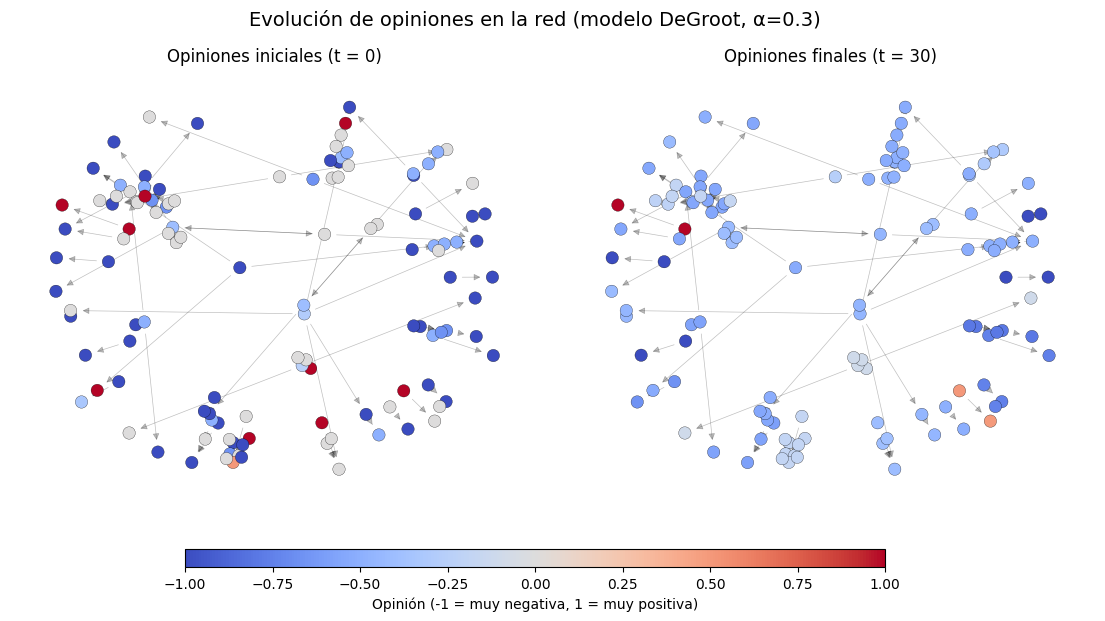

In [69]:
opinions_t0 = history_base[0]
opinions_tT = history_base[-1]

nodes = list(G.nodes())

vmin, vmax = -1.0, 1.0   #rango fijo
cmap = cm.get_cmap("coolwarm")

fig, axes = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={"wspace": 0.05}  #poco espacio entre paneles
)

#Helper para dibujar cada panel
def draw_opinion_panel(ax, opinions, title):
    vals = np.array([opinions[n] for n in nodes])
    colors = [cmap((opinions[n] - vmin) / (vmax - vmin)) for n in nodes]

    nx.draw_networkx_nodes(
        G, pos,
        node_color=colors,
        node_size=80,
        edgecolors="black",
        linewidths=0.2,
        ax=ax
    )
    nx.draw_networkx_edges(
        G, pos,
        alpha=0.25,
        width=0.5,
        ax=ax
    )
    ax.set_title(title, fontsize=12)
    ax.set_axis_off()

draw_opinion_panel(axes[0], opinions_t0, "Opiniones iniciales (t = 0)")
draw_opinion_panel(axes[1], opinions_tT, f"Opiniones finales (t = {T})")

fig.suptitle(f"Evolución de opiniones en la red (modelo DeGroot, α={alpha_base})",
             fontsize=14, y=0.98)

#Colorbar horizontal en la parte inferior
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.03])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Opinión (-1 = muy negativa, 1 = muy positiva)")

plt.subplots_adjust(bottom=0.15)
plt.show()

In [70]:
#Tamaño de cada comunidad
comm_sizes = (
    pd.DataFrame([
        {"community": d["community"], "user": n}
        for n, d in G.nodes(data=True)
    ])
    .groupby("community")["user"].nunique()
    .sort_values(ascending=False)
)

#Tomamos, por ejemplo, las 5 comunidades más grandes
top_k = 5
top_communities = comm_sizes.index[:top_k].tolist()
top_communities

[0, 1, 2, 3, 4]

In [71]:
#Construimos series tiempo-opinión para esas comunidades
rows = []

for t in range(T + 1):
    opinions_t = history_base[t]

    for cid in top_communities:
        nodes_c = [n for n, d in G.nodes(data=True) if d["community"] == cid]
        vals_c = [opinions_t[n] for n in nodes_c if n in opinions_t]
        if len(vals_c) > 0:
            rows.append({
                "t": t,
                "community": cid,
                "op_mean": float(np.mean(vals_c))
            })

comm_time_df = pd.DataFrame(rows)
comm_time_df.head()

,t,community,op_mean
0,0,0,-0.193333
1,0,1,-0.530303
2,0,2,-0.266234
3,0,3,-0.216667
4,0,4,-0.518519


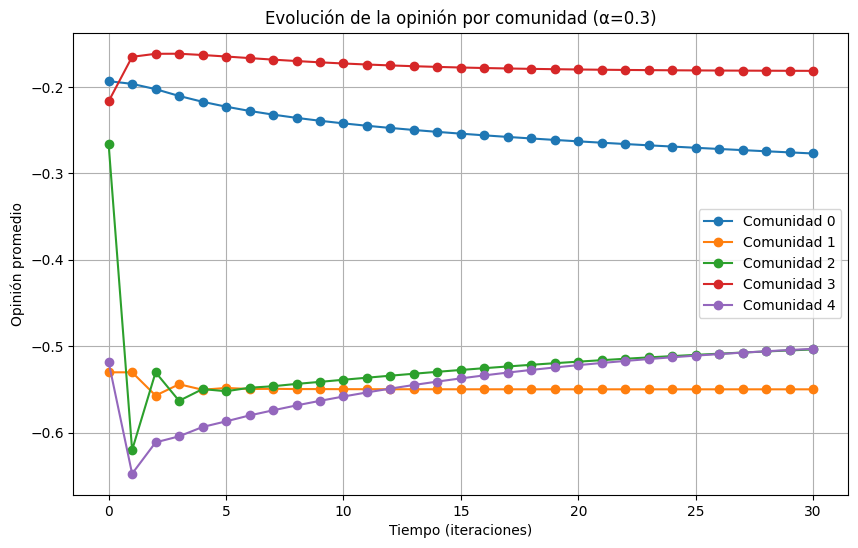

In [72]:
plt.figure(figsize=(10, 6))

for cid in top_communities:
    df_c = comm_time_df[comm_time_df["community"] == cid]
    plt.plot(df_c["t"], df_c["op_mean"], marker="o", label=f"Comunidad {cid}")

plt.xlabel("Tiempo (iteraciones)")
plt.ylabel("Opinión promedio")
plt.title(f"Evolución de la opinión por comunidad (α={alpha_base})")
plt.grid(True)
plt.legend()
plt.show()

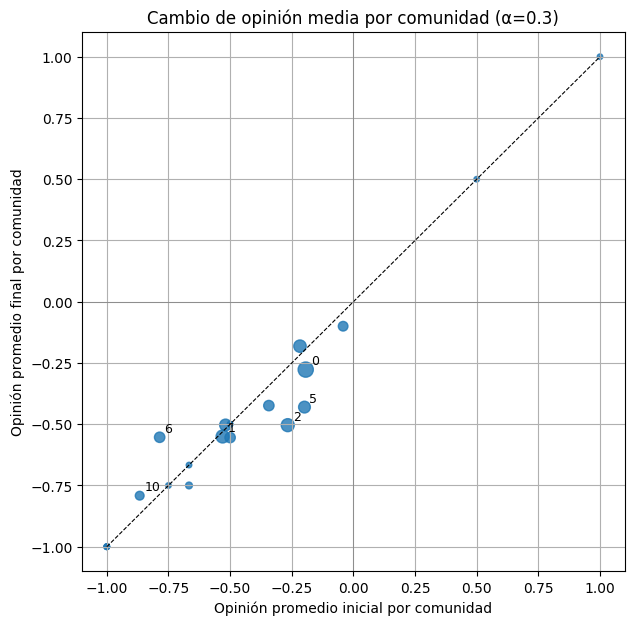

In [73]:
#Construir DataFrame de cambio de opinión por comunidad
rows = []
for cid in sent_df["community"]:
    nodes_c = [n for n, d in G.nodes(data=True) if d["community"] == cid]
    vals0_c = [opinions_t0[n] for n in nodes_c if n in opinions_t0]
    valsT_c = [opinions_tT[n] for n in nodes_c if n in opinions_tT]
    if vals0_c and valsT_c:
        rows.append({
            "community": cid,
            "op0": float(np.mean(vals0_c)),
            "opT": float(np.mean(valsT_c)),
            "n_users": len(nodes_c)
        })

comm_change_df = pd.DataFrame(rows)
comm_change_df["delta"] = comm_change_df["opT"] - comm_change_df["op0"]

#Comunidades que vamos a etiquetar:
#- las 3 más grandes
#- las 2 que más se hicieron menos negativas
#- las 2 que más se hicieron más negativas
label_ids = set()

label_ids.update(comm_change_df.nlargest(3, "n_users")["community"])
label_ids.update(comm_change_df.nlargest(2, "delta")["community"])
label_ids.update(comm_change_df.nsmallest(2, "delta")["community"])

plt.figure(figsize=(7, 7))

sizes = 120 * (comm_change_df["n_users"] / comm_change_df["n_users"].max())

plt.scatter(comm_change_df["op0"], comm_change_df["opT"],
            s=sizes, alpha=0.8)

for _, row in comm_change_df.iterrows():
    cid = int(row["community"])
    if cid in label_ids:
        plt.text(
            row["op0"] + 0.02,
            row["opT"] + 0.02,
            str(cid),
            fontsize=9
        )

#Diagonal (sin cambio)
plt.plot([-1, 1], [-1, 1], "k--", linewidth=0.8)

plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)

plt.xlabel("Opinión promedio inicial por comunidad")
plt.ylabel("Opinión promedio final por comunidad")
plt.title(f"Cambio de opinión media por comunidad (α={alpha_base})")
plt.grid(True)
plt.show()

 ## 3.2 Mapas de polarización

In [74]:
#Construir otra vez tabla de opinión promedio por comunidad
community_sent = {}

for node, data in G.nodes(data=True):
    cid = data.get("community")
    s = data.get("sentiment")
    if cid is not None and s is not None:
        community_sent.setdefault(cid, []).append(s)

sent_df = pd.DataFrame([
    {
        "community": cid,
        "sentiment_mean": np.mean(vals),
        "n_users": len(vals)
    }
    for cid, vals in community_sent.items()
])

#Clasificación en grupos de sentimiento (como antes)
def classify_group(score):
    if score <= -0.6:
        return "muy negativa"
    elif score <= -0.2:
        return "negativa"
    elif score < 0.2:
        return "neutra"
    elif score < 0.6:
        return "positiva"
    else:
        return "muy positiva"

sent_df["grupo_sentimiento"] = sent_df["sentiment_mean"].apply(classify_group)

#Ordenar por sentimiento (de más negativa a más positiva)
sent_df_sorted = sent_df.sort_values("sentiment_mean").reset_index(drop=True)
sent_df_sorted

,community,sentiment_mean,n_users,grupo_sentimiento
0,20,-1.000000,2,muy negativa
1,19,-1.000000,2,muy negativa
2,18,-1.000000,2,muy negativa
3,17,-1.000000,2,muy negativa
4,10,-0.866667,5,muy negativa
...,...,...,...,...
17,5,-0.198413,9,neutra
18,0,-0.193333,15,neutra
19,9,-0.041667,6,neutra
20,15,0.500000,2,positiva


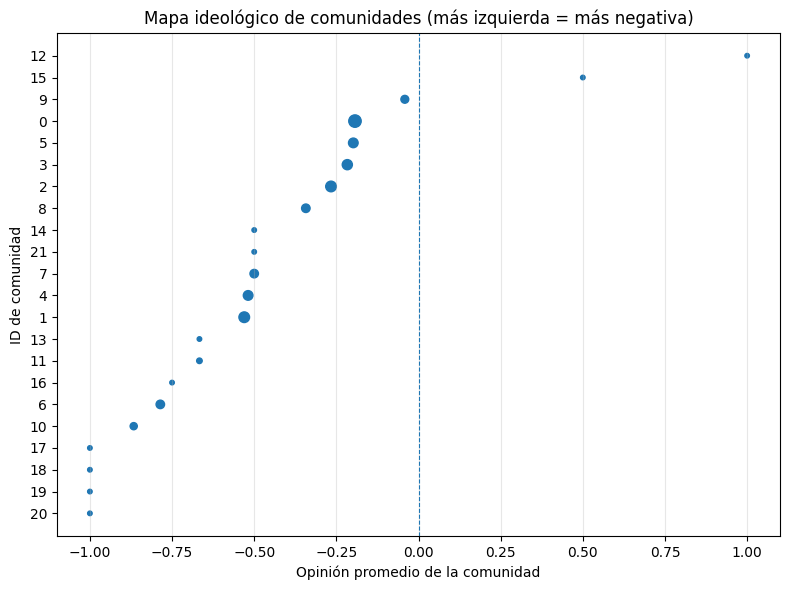

In [75]:
#Asegurarse de tener sent_df con sentiment_mean, n_users y community
community_sent = {}
for node, data in G.nodes(data=True):
    cid = data.get("community")
    s = data.get("sentiment")
    if cid is not None and s is not None:
        community_sent.setdefault(cid, []).append(s)

sent_df = pd.DataFrame([
    {"community": cid, "sentiment_mean": np.mean(vals), "n_users": len(vals)}
    for cid, vals in community_sent.items()
])

#Ordenar comunidades de más negativa a más positiva
sent_df_sorted = sent_df.sort_values("sentiment_mean").reset_index(drop=True)

#Posiciones verticales (una fila por comunidad)
y_pos = np.arange(len(sent_df_sorted))

#Tamaño del punto según el tamaño de la comunidad
sizes = 80 * (sent_df_sorted["n_users"] / sent_df_sorted["n_users"].max())

plt.figure(figsize=(8, 6))
plt.scatter(sent_df_sorted["sentiment_mean"], y_pos, s=sizes)

#Línea vertical en 0 (separa negativas/positivas)
plt.axvline(0, linestyle="--", linewidth=0.8)

plt.yticks(y_pos, sent_df_sorted["community"])
plt.xlabel("Opinión promedio de la comunidad")
plt.ylabel("ID de comunidad")
plt.title("Mapa ideológico de comunidades (más izquierda = más negativa)")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

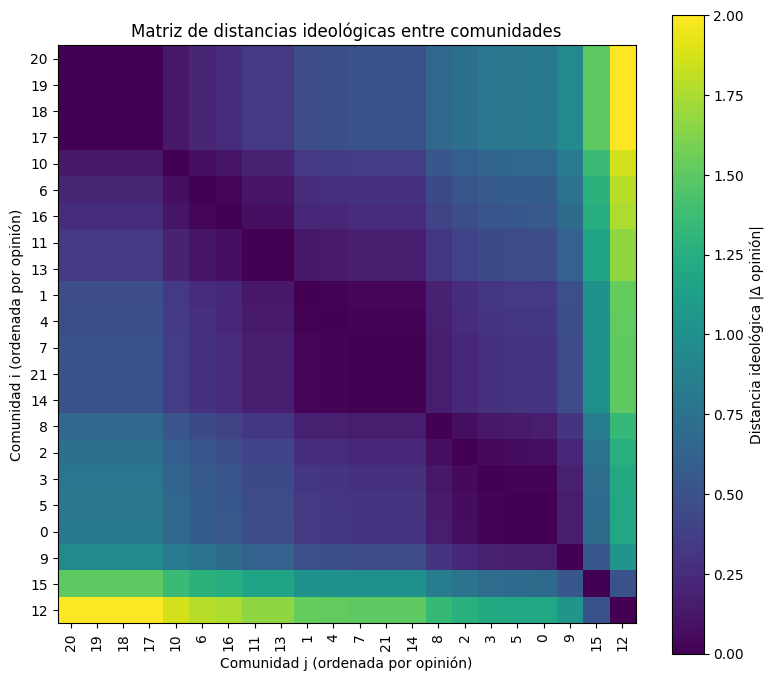

In [76]:
#Reordenamos comunidades de más negativa a más positiva
comm_ids = sent_df_sorted["community"].tolist()
means = sent_df_sorted["sentiment_mean"].values

n = len(comm_ids)
D = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        D[i, j] = abs(means[i] - means[j])

plt.figure(figsize=(8, 7))
im = plt.imshow(D, cmap="viridis")

plt.colorbar(im, label="Distancia ideológica |Δ opinión|")

plt.xticks(range(n), comm_ids, rotation=90)
plt.yticks(range(n), comm_ids)

plt.xlabel("Comunidad j (ordenada por opinión)")
plt.ylabel("Comunidad i (ordenada por opinión)")
plt.title("Matriz de distancias ideológicas entre comunidades")
plt.tight_layout()
plt.show()

In [77]:
#Buscamos los pares de comunidades más alejadas
pairs = []

for i in range(n):
    for j in range(i + 1, n):
        pairs.append({
            "c1": comm_ids[i],
            "c2": comm_ids[j],
            "dist": D[i, j]
        })

pairs_df = pd.DataFrame(pairs).sort_values("dist", ascending=False)
pairs_df.head(10)

,c1,c2,dist
20,20,12,2.000000
59,18,12,2.000000
40,19,12,2.000000
77,17,12,2.000000
94,10,12,1.866667
110,6,12,1.785714
125,16,12,1.750000
139,11,12,1.666667
152,13,12,1.666667
164,1,12,1.530303


 ## 3.3 Implicancias sociales y éticas

Los resultados muestran que la conversación en torno al apagón tiende a un consenso fuertemente negativo, dominado por comunidades grandes y críticas, mientras que las voces positivas o moderadas son minoritarias y estructuralmente periféricas. Esto sugiere un riesgo de sobrerrepresentación del malestar y de validación casi automática de narrativas muy críticas, especialmente si se combinan con desinformación o teorías conspirativas.

Desde el punto de vista de las plataformas digitales, esto plantea la responsabilidad de no reforzar mecánicamente las cámaras de eco ni premiar solo el contenido que genera indignación. Los resultados de simulación indican que eliminar conexiones entre comunidades aumenta la fragmentación, mientras que crear puentes entre grupos opuestos reduce la distancia ideológica y modera el consenso negativo. Esto sugiere que los algoritmos de recomendación deberían favorecer cierta exposición cruzada a puntos de vista distintos (sin promover contenido tóxico) y acompañarse de políticas claras de moderación ante abuso o discurso de odio.

Por parte de los usuarios, los hallazgos subrayan la necesidad de un consumo más crítico y responsable de información: contrastar fuentes, no confundir el “clima” de su burbuja con la opinión general, y evitar contribuir a la escalada de hostilidad. Las comunidades y usuarios más moderados, que en el modelo actúan como “puentes”, tienen un rol potencialmente clave para introducir matices, datos y desacuerdos razonables en contextos de alta emocionalidad.

---

## Preguntas orientadoras:

---

• **¿Qué patrones visuales reflejan la polarización o el consenso?**

Los grafos t=0 vs t=30 muestran homogeneización de colores: al final casi todos los nodos quedan con tonos similares, por lo que hay un consenso negativo más que dos bloques enfrentados. Las curvas de opinión por comunidad se juntan en un rango estrecho de valores negativos, así que las comunidades convergen entre sí. El mapa ideológico 1D muestra muchas comunidades agrupadas entre –1 y –0.3 y solo dos muy pequeñas en el lado positivo, lo que implica una fuerte inclinación hacia un lado, no dos polos simétricos. Y, además, la matriz de distancias ideológicas tiene un gran bloque oscuro (comunidades similares) y solo unos pocos pares muy claros (extremos), con lo cual hay pocas comunidades realmente alejadas.

---

• **¿Qué implicancias tienen los hallazgos para el diseño de sistemas más
resilientes a la desinformación o la radicalización?**

Como el sistema converge a un consenso negativo dominante, los algoritmos que solo refuerzan afinidad pueden sobreamplificar el malestar y dejar casi invisibles las voces moderadas o informativas. Las simulaciones muestran que cámaras de eco (cortar conexiones entre comunidades) mantienen o aumentan la fragmentación, mientras que añadir puentes entre grupos opuestos reduce la distancia ideológica y modera el consenso.

Por tanto, sistemas más resilientes deberían:

- Evitar diseños que refuercen solo burbujas y contenido indignado.

- Introducir exposición controlada a otros puntos de vista y contenido verificado.

- Monitorizar micro-comunidades muy extremas por posibles dinámicas de odio o desinformación organizada.

---

## **Discusión Final:**

En conjunto, el análisis muestra que la conversación sobre el apagón de febrero de 2025 en Chile no se organiza en dos bloques ideológicos simétricos, sino en un clima fuertemente negativo con pequeñas variaciones internas. La red de interacciones revela múltiples comunidades, pero la mayoría presenta opiniones negativas o muy negativas, mientras que las pocas comunidades positivas son pequeñas y periféricas. Visualmente, esto se refleja en grafos donde los colores convergen hacia tonos similares, en mapas ideológicos donde casi todos los puntos se agrupan en el lado negativo, y en matrices de distancia donde solo unos pocos pares de comunidades aparecen realmente alejados.

La dinámica de opinión modelada con DeGroot refuerza esta idea: la red tiende a un consenso crítico moderado, reduciendo algo los extremos pero sin generar un verdadero equilibrio entre posturas. La mayor parte de la influencia recae en comunidades grandes y muy conectadas que ya partían siendo negativas, mientras que las voces moderadas o positivas tienen un impacto limitado. Cuando se alteran las conexiones entre comunidades, las simulaciones muestran que las cámaras de eco mantienen o aumentan la fragmentación entre grupos, mientras que los puentes entre comunidades opuestas reducen la distancia ideológica y suavizan el consenso negativo.

Estos hallazgos tienen implicancias directas para el diseño de plataformas digitales: algoritmos que solo premian afinidad y engagement pueden consolidar un relato dominante y poco matizado, favoreciendo la desinformación y la radicalización en torno a eventos sensibles. Sistemas más resilientes deberían, en cambio, favorecer cierta exposición cruzada a otros puntos de vista, dar visibilidad a contenido contextualizado o verificado, y monitorear micro-comunidades extremadamente negativas sin penalizar la crítica legítima. Del lado de los usuarios, los resultados subrayan la necesidad de un consumo más crítico y responsable de la información, reconociendo que lo que se ve en la propia burbuja no siempre refleja la diversidad real de opiniones presentes en la red.